# MacroAnchor Sparse Curve Allocation V4 — Cost-aware allocation with spanning diagnostics

This notebook extends CurveRV V2 in two directions:

1. **Sparse greedy curve allocation with implementation controls**: the core remains the tenor with the highest pure expected return; additional tenors are retained only when they improve the risk-adjusted profile. V3 adds smoothing, no-trade bands, quarterly rebalance variants and implementation hurdles.
2. **More defensible transaction-cost treatment**: the default live estimate uses a Corwin--Schultz high--low spread estimator on liquid Treasury ETF proxies when OHLC data are available. Fixed bps grids remain only as sensitivity checks.

Reading rule: if the smoothed sparse allocators keep the V2 improvement after empirical/dynamic costs, the extension becomes a promising **sparse yield-curve allocation** project. If only 10Y timing survives, the paper core remains a 10Y bond-risk-premium signal. If residualized market-neutral RV survives after costs, then the extension can be upgraded toward yield-curve relative value.


In [1]:
# ===== 0. Settings =====
from pathlib import Path
import io
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi": 115, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25})

START = "1961-01-01"
END = str(pd.Timestamp.today().date())
CACHE_DIR = Path("macroanchor_curve_rv_cache")
OUT_DIR = Path("macroanchor_curve_rv_v3_outputs")
CACHE_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

# Main research settings
TENORS = [2, 3, 5, 7, 10]              # traded tenors
CURVE_MATS = [1, 2, 3, 5, 7, 10]       # observed CMT tenors used for interpolation
H = 12                                  # 12-month bond-risk-premium target
MINW = 120                              # expanding-window burn-in
PI_HL = 36                              # inflation trend EWMA half-life in months
RSTAR_HL = 120                          # neutral real-rate proxy half-life in months

# Score construction: "forecast_er_vol" or "tp_z"
SCORE_MODE = "forecast_er_vol"

# Strategy / implementation settings
VOL_TARGET = None       # e.g. 0.06 for 6% annualized ex-ante targeting; None leaves raw weights
VOL_LOOKBACK = 36
MAX_LEVERAGE = 2.0
REQUIRE_POSITIVE_FOR_LONG_ONLY = True
COST_BPS_GRID = [0, 5, 10, 25]

# V2 sparse/greedy settings
CORE_MIN_WEIGHT = 0.50          # keep the pure-return core economically relevant
SATELLITE_GRID = np.round(np.arange(0.05, 0.55, 0.05), 2)
SHORT_HEDGE_GRID = np.round(np.arange(0.05, 0.55, 0.05), 2)
RISK_LOOKBACK = 60              # monthly observations for conditional covariances
MIN_IMPROVEMENT = 1e-4          # objective improvement required to accept a new leg
MIN_RETENTION_OF_CORE_ER = 0.65 # satellites may diversify, but should not destroy expected return
MAX_GROSS_GREEDY = 2.0
CARRY_WEIGHT = 0.35             # used only in residualized carry-aware RV track
SMOOTH_ALPHA = 0.35             # weight smoothing for turnover control in RV track

print("MacroAnchor CurveRV V3")
print("TENORS:", TENORS)
print("SCORE_MODE:", SCORE_MODE)

MacroAnchor CurveRV V3
TENORS: [2, 3, 5, 7, 10]
SCORE_MODE: forecast_er_vol


In [2]:
# ===== 1. Data layer: FRED with cache/fallback =====
def _read_fredgraph_csv(series_id: str) -> pd.Series:
    """Read one FRED series using fredgraph CSV; cache locally."""
    cache_path = CACHE_DIR / f"{series_id}.csv"
    if cache_path.exists():
        df = pd.read_csv(cache_path)
    else:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        try:
            # avoid compressed responses that sometimes trigger decode issues
            req = urllib.request.Request(url, headers={"Accept-Encoding": "identity", "User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=30) as resp:
                raw = resp.read()
            text = raw.decode("utf-8-sig", errors="replace")
            df = pd.read_csv(io.StringIO(text))
            df.to_csv(cache_path, index=False)
        except Exception as e:
            if cache_path.exists():
                warnings.warn(f"FRED download failed for {series_id}; using cache. Error: {e}")
                df = pd.read_csv(cache_path)
            else:
                raise RuntimeError(f"Cannot fetch {series_id} and no cache exists. Error: {e}")
    df.columns = ["date", "value"]
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    s = pd.to_numeric(df["value"], errors="coerce")
    return pd.Series(s.values, index=df["date"], name=series_id).sort_index()


def fred_series(ids, start=START, end=END) -> pd.DataFrame:
    ids = ids if isinstance(ids, list) else [ids]
    # Prefer pandas_datareader if available; fallback to cached fredgraph CSV
    try:
        import pandas_datareader.data as web
        df = web.DataReader(ids, "fred", start, end)
        if df is not None and len(df.dropna(how="all")):
            return df
    except Exception as e:
        warnings.warn(f"pandas_datareader failed ({e}); using fredgraph CSV/cache.")
    out = {sid: _read_fredgraph_csv(sid) for sid in ids}
    df = pd.DataFrame(out)
    return df.loc[pd.to_datetime(start):pd.to_datetime(end)]


def ewma(series, halflife):
    return pd.Series(series).ewm(halflife=halflife, adjust=False).mean()

In [3]:
# ===== 2. Fetch and align US curve, short rate, CPI =====
ids_curve = {1: "GS1", 2: "GS2", 3: "GS3", 5: "GS5", 7: "GS7", 10: "GS10"}
raw = fred_series(list(ids_curve.values()) + ["TB3MS", "CPIAUCSL"])
raw.index = pd.to_datetime(raw.index)
raw_m = raw.resample("ME").last()

curve = pd.DataFrame({m: raw_m[ids_curve[m]] for m in CURVE_MATS}) / 100.0
short = raw_m["TB3MS"] / 100.0
cpi = raw_m["CPIAUCSL"]

idx = curve.dropna().index.intersection(short.dropna().index).intersection(cpi.dropna().index)
curve = curve.loc[idx].copy()
short = short.loc[idx].copy()
cpi = cpi.loc[idx].copy()

# Trim to start where all relevant tenors are available
valid = curve.dropna().index.intersection(short.dropna().index).intersection(cpi.dropna().index)
curve, short, cpi = curve.loc[valid], short.loc[valid], cpi.loc[valid]
dates = curve.index
Y = curve.values.astype(float)
r = short.values.astype(float)
Tn = len(dates)
TAUS = np.array(CURVE_MATS, dtype=float)

print(f"Sample: {dates[0].date()} to {dates[-1].date()} | n={Tn}")
print("Curve columns:", curve.columns.tolist())
display(curve.tail())

Sample: 1976-06-30 to 2026-08-31 | n=602
Curve columns: [1, 2, 3, 5, 7, 10]


,1,2,3,5,7,10
DATE,,,,,,
2026-04-30,0.0369,0.0380,0.0382,0.0394,0.0412,0.0432
2026-05-31,0.0379,0.0400,0.0404,0.0415,0.0431,0.0448
2026-06-30,0.0391,0.0411,0.0415,0.0421,0.0433,0.0447
2026-07-31,0.0405,0.0422,0.0426,0.0433,0.0446,0.0460
2026-08-31,0.0403,0.0422,0.0428,0.0438,0.0452,0.0468


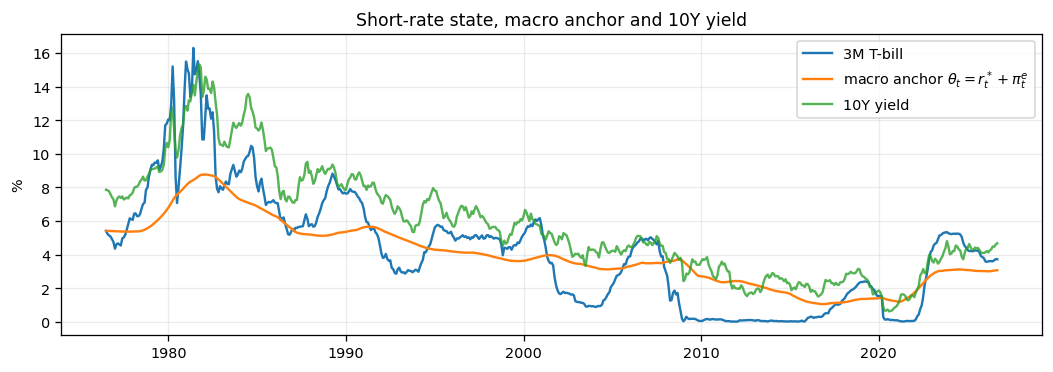

Latest:
3M rate: 3.72% | r*: -0.23% | pi_e: 3.30% | anchor: 3.07%


In [4]:
# ===== 3. Macro anchor: theta(t) = r*_t + pi_e,t =====
# Trend inflation: EWMA of trailing YoY CPI.
# r*: slow EWMA of realized real short rate, deliberately simple and reproducible.
cpi_yoy = np.log(cpi).diff(12)
pi_trend = cpi_yoy.ewm(halflife=PI_HL, adjust=False).mean().bfill()
rstar = (short - pi_trend).ewm(halflife=RSTAR_HL, adjust=False).mean().bfill()
anchor = (rstar + pi_trend).reindex(dates).bfill().ffill()

plt.figure(figsize=(11, 3.4))
plt.plot(dates, short * 100, label="3M T-bill")
plt.plot(dates, anchor * 100, label=r"macro anchor $\theta_t=r^*_t+\pi^e_t$")
plt.plot(dates, curve[10] * 100, label="10Y yield", alpha=0.8)
plt.title("Short-rate state, macro anchor and 10Y yield")
plt.ylabel("%")
plt.legend()
plt.show()

print("Latest:")
print(f"3M rate: {short.iloc[-1]*100:.2f}% | r*: {rstar.iloc[-1]*100:.2f}% | pi_e: {pi_trend.iloc[-1]*100:.2f}% | anchor: {anchor.iloc[-1]*100:.2f}%")

Full-sample-ish latest expanding HW estimate:
kappa=0.1618, half-life=51.4m, sigma=1.48%, gap t=1.52


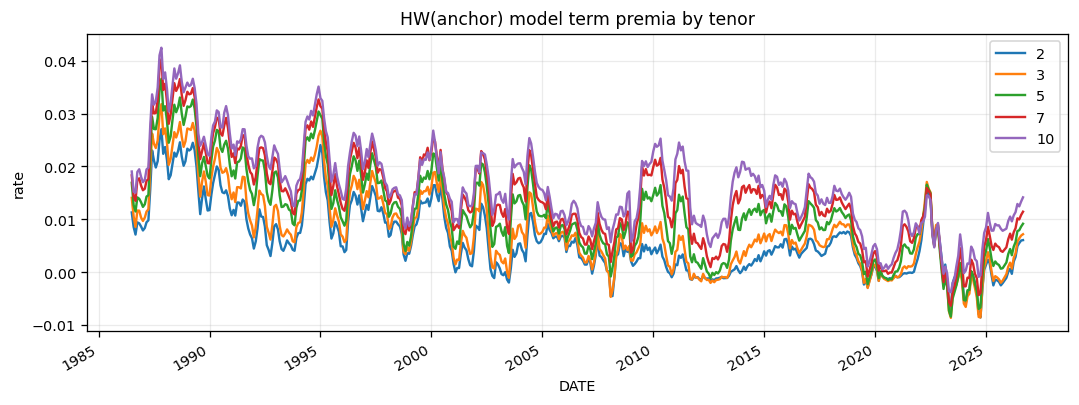

In [5]:
# ===== 4. HW(anchor) estimation under P and pure-expectations term premia =====
DT = 1/12

def fit_hw(rw, anc):
    """Regress monthly dr on anchor gap; annualize kappa/sigma."""
    rw = np.asarray(rw, float); anc = np.asarray(anc, float)
    g = anc[:len(rw)-1] - rw[:-1]
    d = rw[1:] - rw[:-1]
    m = np.isfinite(g) & np.isfinite(d)
    if m.sum() < 24 or np.nanvar(g[m]) < 1e-12:
        return np.nan, np.nan, np.nan
    X = np.column_stack([np.ones(m.sum()), g[m]])
    a0, sl = np.linalg.lstsq(X, d[m], rcond=None)[0]
    e = d[m] - (a0 + sl*g[m])
    denom = np.sum((g[m] - g[m].mean())**2)
    if denom <= 0 or len(e) <= 2:
        tstat = np.nan
    else:
        seb = np.sqrt(np.sum(e*e)/(len(e)-2)/denom)
        tstat = sl/seb if seb > 0 else np.nan
    k = float(np.clip(sl * 12, 1e-4, 20.0))
    sigma = float(np.nanstd(e) * np.sqrt(12))
    return k, sigma, float(tstat)


def vas_B(tau, k):
    k = max(float(k), 1e-4)
    return (1 - np.exp(-k*tau)) / k


def vas_yield(tau, rr, k, theta, sigma):
    k = max(float(k), 1e-4)
    B = vas_B(tau, k)
    lnA = (theta - sigma*sigma/(2*k*k))*(B - tau) - sigma*sigma*B*B/(4*k)
    return (-lnA + B*rr) / tau

# Expanding estimates
k_hw = np.full(Tn, np.nan)
sig_hw = np.full(Tn, np.nan)
t_hw = np.full(Tn, np.nan)
for t in range(MINW, Tn):
    k_hw[t], sig_hw[t], t_hw[t] = fit_hw(r[:t+1], anchor.values[:t+1])

# Model-implied pure-expectations yields and term premia by observed tenor
YPE = np.full_like(Y, np.nan, dtype=float)
TPHW = np.full_like(Y, np.nan, dtype=float)
for t in range(MINW, Tn):
    for j, tau in enumerate(TAUS):
        YPE[t, j] = vas_yield(tau, r[t], k_hw[t], anchor.iloc[t], sig_hw[t])
        TPHW[t, j] = Y[t, j] - YPE[t, j]

tp_df = pd.DataFrame(TPHW, index=dates, columns=CURVE_MATS)
print("Full-sample-ish latest expanding HW estimate:")
print(f"kappa={k_hw[np.isfinite(k_hw)][-1]:.4f}, half-life={np.log(2)/k_hw[np.isfinite(k_hw)][-1]*12:.1f}m, sigma={sig_hw[np.isfinite(sig_hw)][-1]*100:.2f}%, gap t={t_hw[np.isfinite(t_hw)][-1]:.2f}")

tp_df[TENORS].plot(figsize=(11, 3.8), title="HW(anchor) model term premia by tenor")
plt.ylabel("rate")
plt.show()

In [6]:
# ===== 5. Exact 12m Fama-Bliss-style targets and monthly excess returns =====
def y_at_date(t, mat):
    return float(np.interp(mat, TAUS, Y[t]))

# 12m exact excess return per tenor: rx_t = n*y_t(n) - (n-1)*y_{t+12}(n-1) - y_t(1)
RX12 = pd.DataFrame(index=dates, columns=TENORS, dtype=float)
y1 = curve[1].values
for n in TENORS:
    for t in range(Tn - H):
        yn = y_at_date(t, n)
        ynm1_next = y_at_date(t + H, n - 1)
        RX12.iloc[t, RX12.columns.get_loc(n)] = n*yn - (n-1)*ynm1_next - y1[t]

# Monthly holding-period return approximation by component.
# Position held from t-1 to t; components are computed at t using previous curve and realised yield change.
ret_total = pd.DataFrame(index=dates, columns=TENORS, dtype=float)
ret_excess = pd.DataFrame(index=dates, columns=TENORS, dtype=float)
comp = {name: pd.DataFrame(index=dates, columns=TENORS, dtype=float) for name in ["carry", "roll", "repricing", "convexity", "funding"]}

for t in range(1, Tn):
    for n in TENORS:
        y_prev = y_at_date(t-1, n)
        y_prev_aged = y_at_date(t-1, max(n - 1/12, 0.25))
        y_now = y_at_date(t, n)
        y_prev_same = y_at_date(t-1, n)
        dy = y_now - y_prev_same
        D = n
        C = n*n
        carry = y_prev / 12
        roll = D * (y_prev - y_prev_aged)
        repricing = -D * dy
        convexity = 0.5 * C * dy * dy
        funding = -short.iloc[t-1] / 12
        total = carry + roll + repricing + convexity
        comp["carry"].iloc[t, comp["carry"].columns.get_loc(n)] = carry
        comp["roll"].iloc[t, comp["roll"].columns.get_loc(n)] = roll
        comp["repricing"].iloc[t, comp["repricing"].columns.get_loc(n)] = repricing
        comp["convexity"].iloc[t, comp["convexity"].columns.get_loc(n)] = convexity
        comp["funding"].iloc[t, comp["funding"].columns.get_loc(n)] = funding
        ret_total.iloc[t, ret_total.columns.get_loc(n)] = total
        ret_excess.iloc[t, ret_excess.columns.get_loc(n)] = total + funding

print("12m exact targets preview:")
display(RX12[TENORS].dropna().head())
print("Monthly excess return approximation preview:")
display(ret_excess[TENORS].dropna().head())

12m exact targets preview:


,2,3,5,7,10
DATE,,,,,
1976-06-30,0.0180,0.0315,0.0523,0.0630,0.0725
1976-07-31,0.0156,0.0262,0.0455,0.0582,0.0676
1976-08-31,0.0089,0.0136,0.0291,0.0425,0.0558
1976-09-30,0.0047,0.0072,0.0205,0.0328,0.0439
1976-10-31,-0.0051,-0.0100,-0.0077,0.0034,0.0116


Monthly excess return approximation preview:


,2,3,5,7,10
DATE,,,,,
1976-07-31,0.0065,0.0079,0.0085,0.0059,0.0054
1976-08-31,0.0068,0.0101,0.0117,0.0111,0.0085
1976-09-30,0.0065,0.0080,0.0118,0.0148,0.0209
1976-10-31,0.0109,0.0146,0.0219,0.0204,0.0208
1976-11-30,0.0051,0.0063,0.0142,0.0243,0.0148


In [7]:
# ===== 6. Expanding forecasts, z-scores and cross-tenor scores =====
def nw_tstat(y, x, lag=12):
    y = np.asarray(y, float); x = np.asarray(x, float)
    m = np.isfinite(y) & np.isfinite(x)
    y = y[m]; x = x[m]
    if len(y) < 36 or np.nanstd(x) < 1e-12:
        return np.nan, np.nan, np.nan
    X = np.column_stack([np.ones(len(x)), x])
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    e = y - X @ b
    Z = X * e[:, None]
    S = Z.T @ Z / len(y)
    for L in range(1, min(lag, len(y)-1) + 1):
        w = 1 - L/(lag + 1)
        Gamma = Z[L:].T @ Z[:-L] / len(y)
        S += w * (Gamma + Gamma.T)
    XX = X.T @ X / len(y)
    V = np.linalg.pinv(XX) @ S @ np.linalg.pinv(XX) / len(y)
    se = np.sqrt(np.diag(V))
    t = b[1]/se[1] if se[1] > 0 else np.nan
    r2 = 1 - np.sum(e*e)/np.sum((y - y.mean())**2)
    return b[1], t, r2


def expanding_forecast(x, y, minw=MINW, horizon=H):
    """Forecast y[t] using x[t], training only on origins s<=t-horizon."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    yhat = np.full(len(y), np.nan)
    volhat = np.full(len(y), np.nan)
    beta = np.full(len(y), np.nan)
    for t in range(minw + horizon, len(y)):
        train_idx = np.arange(0, t - horizon + 1)
        m = np.isfinite(x[train_idx]) & np.isfinite(y[train_idx])
        if m.sum() < minw or not np.isfinite(x[t]):
            continue
        X = np.column_stack([np.ones(m.sum()), x[train_idx][m]])
        b = np.linalg.lstsq(X, y[train_idx][m], rcond=None)[0]
        res = y[train_idx][m] - X @ b
        yhat[t] = b[0] + b[1]*x[t]
        volhat[t] = np.nanstd(res)
        beta[t] = b[1]
    return yhat, volhat, beta


def expanding_z(x, minw=MINW):
    x = np.asarray(x, float)
    z = np.full(len(x), np.nan)
    for t in range(minw, len(x)):
        hist = x[:t]
        hist = hist[np.isfinite(hist)]
        if len(hist) < minw or hist.std() < 1e-12 or not np.isfinite(x[t]):
            continue
        z[t] = (x[t] - hist.mean()) / hist.std()
    return z

# Build tenor-level predictors and scores.
forecast_er = pd.DataFrame(index=dates, columns=TENORS, dtype=float)
forecast_vol = pd.DataFrame(index=dates, columns=TENORS, dtype=float)
tp_z = pd.DataFrame(index=dates, columns=TENORS, dtype=float)
beta_exp = pd.DataFrame(index=dates, columns=TENORS, dtype=float)
insample_rows = []

for n in TENORS:
    x = tp_df[n].values
    y = RX12[n].values
    yh, vh, bh = expanding_forecast(x, y)
    forecast_er[n] = yh
    forecast_vol[n] = vh
    beta_exp[n] = bh
    tp_z[n] = expanding_z(x)
    b, tstat, r2 = nw_tstat(y, x, lag=12)
    insample_rows.append({"tenor": n, "beta_per_1SD_%": b*np.nanstd(x)*100 if np.isfinite(b) else np.nan, "NW_t": tstat, "R2": r2})

if SCORE_MODE == "forecast_er_vol":
    score = forecast_er / forecast_vol.replace(0, np.nan)
elif SCORE_MODE == "tp_z":
    score = tp_z.copy()
else:
    raise ValueError("Unknown SCORE_MODE")

score = score.replace([np.inf, -np.inf], np.nan)
print("In-sample predictive regressions: RX12 ~ TP_HW")
display(pd.DataFrame(insample_rows).set_index("tenor"))
print("Score preview")
display(score.dropna(how="all").tail())

In-sample predictive regressions: RX12 ~ TP_HW


,beta_per_1SD_%,NW_t,R2
tenor,,,
2,0.2987,2.1826,0.0494
3,0.5335,2.0841,0.0459
5,1.2591,2.5969,0.0790
7,1.9950,3.0307,0.1086
10,3.1986,3.4480,0.1487


Score preview


,2,3,5,7,10
DATE,,,,,
2026-04-30,0.3257,0.2585,0.2038,0.1722,0.0981
2026-05-31,0.3942,0.3203,0.2755,0.2467,0.1730
2026-06-30,0.4131,0.3365,0.2803,0.2386,0.1513
2026-07-31,0.4291,0.3505,0.3034,0.2720,0.1955
2026-08-31,0.4309,0.3568,0.3210,0.2961,0.2339


In [8]:
# ===== 7. V1 benchmark strategy weight builders =====
def normalize_gross(w, gross=1.0):
    w = np.asarray(w, float)
    g = np.nansum(np.abs(w))
    if not np.isfinite(g) or g <= 1e-12:
        return np.zeros_like(w)
    return w / g * gross


def weights_A_long_best(score_df):
    W = pd.DataFrame(0.0, index=score_df.index, columns=score_df.columns)
    for t, row in score_df.iterrows():
        x = row.astype(float)
        if x.notna().sum() == 0:
            continue
        best = x.idxmax()
        if REQUIRE_POSITIVE_FOR_LONG_ONLY and x.loc[best] <= 0:
            continue
        W.loc[t, best] = 1.0
    return W


def weights_B_top_bottom(score_df, gross=1.0):
    W = pd.DataFrame(0.0, index=score_df.index, columns=score_df.columns)
    for t, row in score_df.iterrows():
        x = row.astype(float).dropna()
        if len(x) < 2:
            continue
        long_n, short_n = x.idxmax(), x.idxmin()
        if x.loc[long_n] <= x.loc[short_n]:
            continue
        W.loc[t, long_n] = gross/2
        W.loc[t, short_n] = -gross/2
    return W


def weights_C_dv01_neutral(score_df, durations, gross=1.0):
    """Top-bottom trade with equal and opposite DV01, plus implicit cash residual.
    Dollar weights do not sum to zero unless durations are equal; returns are active over cash via excess returns.
    """
    W = pd.DataFrame(0.0, index=score_df.index, columns=score_df.columns)
    D = pd.Series(durations, index=score_df.columns, dtype=float)
    for t, row in score_df.iterrows():
        x = row.astype(float).dropna()
        if len(x) < 2:
            continue
        L, S = x.idxmax(), x.idxmin()
        if x.loc[L] <= x.loc[S]:
            continue
        dL, dS = D.loc[L], D.loc[S]
        wL = gross * dS / (dL + dS)
        wS = -gross * dL / (dL + dS)
        W.loc[t, L] = wL
        W.loc[t, S] = wS
    return W


def pc1_loadings_at(t, lookback=60):
    if t < lookback + 1:
        return None
    dY_hist = curve.diff().iloc[t-lookback:t].dropna()
    if len(dY_hist) < max(24, lookback//2):
        return None
    X = dY_hist[CURVE_MATS].values
    X = X - X.mean(axis=0, keepdims=True)
    cov = np.cov(X, rowvar=False)
    vals, vecs = np.linalg.eigh(cov)
    pc1 = vecs[:, np.argmax(vals)]
    # Orient PC1 to have positive average loading.
    if pc1.mean() < 0:
        pc1 = -pc1
    # Interpolate PC1 loadings to traded tenors.
    return np.interp(TENORS, CURVE_MATS, pc1)


def weights_D_pc1_neutral(score_df, gross=1.0, lookback=60):
    W = pd.DataFrame(0.0, index=score_df.index, columns=score_df.columns)
    D = np.array(TENORS, dtype=float)
    for i, (dt, row) in enumerate(score_df.iterrows()):
        x = row.astype(float).values
        if np.isfinite(x).sum() < 3:
            continue
        # Raw score-sorted portfolio: demean scores, then gross-normalize.
        z = x.copy()
        z[~np.isfinite(z)] = np.nan
        z = z - np.nanmean(z)
        z[~np.isfinite(z)] = 0.0
        w = normalize_gross(z, gross=gross)
        pc1 = pc1_loadings_at(i, lookback=lookback)
        if pc1 is None:
            continue
        # Bond return exposure to PC1 yield move is roughly -D * pc1.
        load = -D * pc1
        denom = float(load @ load)
        if denom > 1e-12:
            w = w - (float(w @ load) / denom) * load
        w = normalize_gross(w, gross=gross)
        W.loc[dt, :] = w
    return W

V1_W = {
    "A_long_best": weights_A_long_best(score),
    "B_top_bottom": weights_B_top_bottom(score),
    "C_DV01_neutral": weights_C_dv01_neutral(score, durations=TENORS),
    "D_PC1_neutral": weights_D_pc1_neutral(score),
}

for k, w in V1_W.items():
    print(k, "avg gross", w.abs().sum(1).replace(0, np.nan).mean(), "avg net", w.sum(1).replace(0, np.nan).mean())

A_long_best avg gross 1.0 avg net 1.0
B_top_bottom avg gross 1.0 avg net nan
C_DV01_neutral avg gross 1.0 avg net 0.6346687816773289
D_PC1_neutral avg gross 1.0 avg net 0.5200465429455309


In [9]:

# ===== 8. V2 conditional-risk and sparse/greedy helpers =====
def safe_std(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    return np.nanstd(x, ddof=1) if len(x) > 1 else np.nan


def cov_at(df, t_pos, lookback=RISK_LOOKBACK, annualize=12.0, min_obs=24):
    """Rolling covariance matrix using rows strictly before t_pos."""
    start = max(0, t_pos - lookback)
    win = df.iloc[start:t_pos].replace([np.inf, -np.inf], np.nan).dropna(how="any")
    n = df.shape[1]
    if len(win) < min_obs:
        return np.eye(n) * 1e-6
    S = np.cov(win.values, rowvar=False)
    if S.ndim == 0:
        S = np.array([[S]])
    # mild diagonal ridge for stability
    diag = np.nanmean(np.diag(S)) if np.isfinite(np.diag(S)).any() else 1e-6
    return (S + np.eye(n) * max(diag, 1e-8) * 1e-4) * annualize


def yield_change_panel():
    dy = curve[CURVE_MATS].diff().reindex(dates)
    return dy[TENORS]

DY_TENOR = yield_change_panel()
D_VEC = np.array(TENORS, dtype=float)


def port_expected_return(w, mu_vec):
    w = np.asarray(w, float)
    mu = np.asarray(mu_vec, float)
    if not np.isfinite(mu).all():
        return np.nan
    return float(w @ mu)


def risk_return_vol(w, S_ret):
    w = np.asarray(w, float)
    return float(np.sqrt(max(w @ S_ret @ w, 0.0)))


def risk_dv01_yield(w, S_dy):
    w = np.asarray(w, float)
    d = D_VEC * w
    return float(np.sqrt(max(d @ S_dy @ d, 0.0)))


def risk_tail_es(w, ret_window, alpha=0.05):
    """Historical monthly ES loss, annualized approximately by sqrt(12)."""
    w = np.asarray(w, float)
    X = ret_window.replace([np.inf, -np.inf], np.nan).dropna(how="any")
    if len(X) < 24:
        return np.nan
    rp = X.values @ w
    q = np.nanquantile(rp, alpha)
    tail = rp[rp <= q]
    if len(tail) == 0:
        return np.nan
    return float(-np.nanmean(tail) * np.sqrt(12))


def objective_ratio(w, mu_vec, risk_value, min_risk=1e-6):
    er = port_expected_return(w, mu_vec)
    if not np.isfinite(er) or not np.isfinite(risk_value) or risk_value <= min_risk:
        return -np.inf
    return er / risk_value


def normalize_long_only(w):
    w = np.maximum(np.asarray(w, float), 0.0)
    s = w.sum()
    return w / s if s > 1e-12 else np.zeros_like(w)


def gross(w):
    return float(np.sum(np.abs(w)))


def select_core(mu_vec):
    """Core is the best pure expected-return tenor, not risk-adjusted."""
    mu = np.asarray(mu_vec, float)
    if not np.isfinite(mu).any():
        return None
    return int(np.nanargmax(mu))


def greedy_long_only_at_t(mu_vec, S_ret=None, S_dy=None, risk_mode="vol", ret_window=None,
                          require_positive_core=True, verbose=False):
    """Sparse long-only allocator: core = best pure ER; satellites improve risk-adjusted objective."""
    mu = np.asarray(mu_vec, float)
    n = len(mu)
    core = select_core(mu)
    if core is None:
        return np.zeros(n)
    if require_positive_core and (not np.isfinite(mu[core]) or mu[core] <= 0):
        return np.zeros(n)

    w = np.zeros(n); w[core] = 1.0
    selected = {core}
    core_er = mu[core]

    def risk(w_):
        if risk_mode == "vol":
            return risk_return_vol(w_, S_ret)
        if risk_mode == "dv01":
            return risk_dv01_yield(w_, S_dy)
        if risk_mode == "es":
            return risk_tail_es(w_, ret_window)
        raise ValueError(risk_mode)

    best_obj = objective_ratio(w, mu, risk(w))
    improved = True
    while improved and len(selected) < n:
        improved = False
        best_candidate = None
        best_w = w.copy()
        best_val = best_obj
        for j in range(n):
            if j in selected or not np.isfinite(mu[j]):
                continue
            for a in SATELLITE_GRID:
                cand = (1-a)*w.copy()
                cand[j] += a
                cand = normalize_long_only(cand)
                # preserve a core allocation floor
                if cand[core] < CORE_MIN_WEIGHT - 1e-12:
                    continue
                er = port_expected_return(cand, mu)
                if not np.isfinite(er) or er < MIN_RETENTION_OF_CORE_ER * core_er:
                    continue
                val = objective_ratio(cand, mu, risk(cand))
                if val > best_val + MIN_IMPROVEMENT:
                    best_val, best_w, best_candidate = val, cand, j
        if best_candidate is not None:
            selected.add(best_candidate)
            w = best_w
            best_obj = best_val
            improved = True
    return w


def greedy_core_short_hedge_at_t(mu_vec, S_dy=None, max_gross=MAX_GROSS_GREEDY, require_positive_core=True):
    """Core best pure ER + short hedge legs accepted only if risk-adjusted profile improves.

    The portfolio keeps net exposure near 1. A short hedge h in tenor j is funded into the core:
    w_core += h, w_j -= h. This tests whether low-ER tenors can hedge DV01/yield-shock risk
    without destroying the expected-return profile.
    """
    mu = np.asarray(mu_vec, float)
    n = len(mu)
    core = select_core(mu)
    if core is None:
        return np.zeros(n)
    if require_positive_core and (not np.isfinite(mu[core]) or mu[core] <= 0):
        return np.zeros(n)

    w = np.zeros(n); w[core] = 1.0
    selected_shorts = set()
    best_obj = objective_ratio(w, mu, risk_dv01_yield(w, S_dy))

    improved = True
    while improved and len(selected_shorts) < n-1:
        improved = False
        best_w = w.copy(); best_j = None; best_val = best_obj
        for j in range(n):
            if j == core or j in selected_shorts or not np.isfinite(mu[j]):
                continue
            for h in SHORT_HEDGE_GRID:
                cand = w.copy()
                cand[core] += h
                cand[j] -= h
                if gross(cand) > max_gross + 1e-12:
                    continue
                er = port_expected_return(cand, mu)
                if not np.isfinite(er) or er < MIN_RETENTION_OF_CORE_ER * mu[core]:
                    continue
                val = objective_ratio(cand, mu, risk_dv01_yield(cand, S_dy))
                if val > best_val + MIN_IMPROVEMENT:
                    best_val, best_w, best_j = val, cand, j
        if best_j is not None:
            w = best_w
            selected_shorts.add(best_j)
            best_obj = best_val
            improved = True
    return w


def build_sparse_greedy_weights():
    cols = TENORS
    W_vol = pd.DataFrame(0.0, index=dates, columns=cols)
    W_dv01 = pd.DataFrame(0.0, index=dates, columns=cols)
    W_short = pd.DataFrame(0.0, index=dates, columns=cols)
    W_es = pd.DataFrame(0.0, index=dates, columns=cols)

    for tpos, dt in enumerate(dates):
        if tpos < MINW + H:
            continue
        mu = forecast_er.loc[dt, cols].astype(float).values
        if not np.isfinite(mu).any():
            continue
        S_ret = cov_at(ret_excess[cols], tpos, lookback=RISK_LOOKBACK, annualize=12.0)
        S_dy = cov_at(DY_TENOR[cols], tpos, lookback=RISK_LOOKBACK, annualize=12.0)
        ret_win = ret_excess[cols].iloc[max(0, tpos-RISK_LOOKBACK):tpos]

        W_vol.loc[dt, cols] = greedy_long_only_at_t(mu, S_ret=S_ret, risk_mode="vol")
        W_dv01.loc[dt, cols] = greedy_long_only_at_t(mu, S_dy=S_dy, risk_mode="dv01")
        W_short.loc[dt, cols] = greedy_core_short_hedge_at_t(mu, S_dy=S_dy)
        W_es.loc[dt, cols] = greedy_long_only_at_t(mu, risk_mode="es", ret_window=ret_win)

    return {
        "G1_sparse_core_vol": W_vol,
        "G2_sparse_core_dv01": W_dv01,
        "G3_core_short_dv01": W_short,
        "G4_core_tail_es": W_es,
    }

G_WEIGHTS = build_sparse_greedy_weights()
for name, w in G_WEIGHTS.items():
    print(name, "avg gross", w.abs().sum(1).replace(0, np.nan).mean(), "avg net", w.sum(1).replace(0, np.nan).mean())
    display(w.loc[dates[MINW+H]:].mean().to_frame("avg_weight").T.round(3))


G1_sparse_core_vol avg gross 1.0 avg net 1.0


,2,3,5,7,10
avg_weight,0.3000,0.1950,0.0630,0.1040,0.0800


G2_sparse_core_dv01 avg gross 1.0 avg net 1.0


,2,3,5,7,10
avg_weight,0.2960,0.1980,0.0650,0.1040,0.0800


G3_core_short_dv01 avg gross 1.7421203438395416 avg net 1.0


,2,3,5,7,10
avg_weight,0.2350,0.1740,0.1400,0.2580,-0.0640


G4_core_tail_es avg gross 1.0 avg net 1.0


,2,3,5,7,10
avg_weight,0.3260,0.1790,0.0620,0.0940,0.0820


In [10]:

# ===== 9. V2 residualized/carry-aware RV score builders =====
def cross_sectional_demean(df):
    return df.sub(df.mean(axis=1), axis=0)


def residualize_on_tenor(df):
    """For each date, remove cross-sectional intercept and linear tenor slope from the score."""
    out = pd.DataFrame(index=df.index, columns=df.columns, dtype=float)
    x = np.asarray(df.columns, dtype=float)
    Xbase = np.column_stack([np.ones(len(x)), x])
    for dt, row in df.iterrows():
        y = row.astype(float).values
        m = np.isfinite(y)
        if m.sum() < 3:
            continue
        X = Xbase[m]
        b = np.linalg.lstsq(X, y[m], rcond=None)[0]
        res = np.full(len(y), np.nan)
        res[m] = y[m] - X @ b
        out.loc[dt, :] = res
    return out


def carry_roll_forecast_panel():
    """One-month carry + roll-down forecast, computed from information at t only."""
    out = pd.DataFrame(index=dates, columns=TENORS, dtype=float)
    for t in range(Tn):
        for n in TENORS:
            y_n = y_at_date(t, n)
            y_aged = y_at_date(t, max(n - 1/12, 0.25))
            D = n
            carry = y_n / 12
            roll = D * (y_n - y_aged)
            out.iloc[t, out.columns.get_loc(n)] = carry + roll
    return out


def expanding_z_df(df, minw=MINW):
    out = pd.DataFrame(index=df.index, columns=df.columns, dtype=float)
    for c in df.columns:
        out[c] = expanding_z(df[c].values, minw=minw)
    return out

carry_roll_fcst = carry_roll_forecast_panel()
carry_z = cross_sectional_demean(expanding_z_df(carry_roll_fcst))
tp_rel = residualize_on_tenor(tp_z[TENORS])
# This is a pure relative-value score: TP residual after removing common level and maturity slope,
# plus a modest carry/roll score to avoid systematically negative carry spreads.
rv_score = (tp_rel + CARRY_WEIGHT * carry_z).replace([np.inf, -np.inf], np.nan)


def weights_top2_bottom2(score_df, gross=1.0):
    W = pd.DataFrame(0.0, index=score_df.index, columns=score_df.columns)
    for dt, row in score_df.iterrows():
        x = row.astype(float).dropna()
        if len(x) < 4:
            continue
        top = x.nlargest(2).index
        bot = x.nsmallest(2).index
        w = pd.Series(0.0, index=score_df.columns)
        w[top] = +0.25 * gross
        w[bot] = -0.25 * gross
        W.loc[dt, :] = w
    return W


def project_dv01_neutral_weights(W_in):
    """Project each row onto zero DV01 exposure and re-normalize to same gross."""
    W = W_in.copy().astype(float)
    d = pd.Series(TENORS, index=W.columns, dtype=float)
    for dt in W.index:
        w = W.loc[dt].values.astype(float)
        g = np.sum(np.abs(w))
        if g <= 1e-12:
            continue
        load = d.values
        denom = float(load @ load)
        if denom > 1e-12:
            w = w - (float(w @ load) / denom) * load
        gg = np.sum(np.abs(w))
        if gg > 1e-12:
            w = w / gg * g
        W.loc[dt, :] = w
    return W


def smooth_weights(W_in, alpha=SMOOTH_ALPHA, no_trade_band=0.02):
    W = W_in.copy().astype(float)
    out = pd.DataFrame(0.0, index=W.index, columns=W.columns)
    prev = np.zeros(W.shape[1])
    for i, dt in enumerate(W.index):
        target = W.iloc[i].values.astype(float)
        if np.nansum(np.abs(target - prev)) < no_trade_band:
            new = prev
        else:
            new = (1-alpha)*prev + alpha*target
        out.iloc[i, :] = new
        prev = new
    return out

R1 = weights_top2_bottom2(tp_rel[TENORS], gross=1.0)
R2 = project_dv01_neutral_weights(weights_top2_bottom2(rv_score[TENORS], gross=1.0))
R3 = smooth_weights(R2, alpha=SMOOTH_ALPHA, no_trade_band=0.02)

R_WEIGHTS = {
    "R1_resid_top2_bottom2": R1,
    "R2_resid_carry_dv01": R2,
    "R3_resid_carry_dv01_smooth": R3,
}

print("Residualized RV score preview")
display(rv_score.dropna(how="all").tail())
for name, w in R_WEIGHTS.items():
    print(name, "avg gross", w.abs().sum(1).replace(0, np.nan).mean(), "avg net", w.sum(1).replace(0, np.nan).mean())
    display(w.loc[dates[MINW+H]:].mean().to_frame("avg_weight").T.round(3))


Residualized RV score preview


,2,3,5,7,10
DATE,,,,,
2026-04-30,0.1147,-0.0029,-0.1092,-0.0791,0.0765
2026-05-31,0.1339,0.0079,-0.1164,-0.0938,0.0683
2026-06-30,0.1460,0.0345,-0.1308,-0.1193,0.0696
2026-07-31,0.1414,0.0273,-0.1296,-0.1094,0.0704
2026-08-31,0.1234,0.0272,-0.1136,-0.1080,0.0709


R1_resid_top2_bottom2 avg gross 1.0 avg net nan


,2,3,5,7,10
avg_weight,0.0810,-0.0120,-0.0760,-0.0570,0.0630


R2_resid_carry_dv01 avg gross 1.0 avg net 0.0826517250589955


,2,3,5,7,10
avg_weight,0.0750,0.0400,-0.0620,-0.0520,0.0400


R3_resid_carry_dv01_smooth avg gross 0.893292116938227 avg net 0.05500118003727143


,2,3,5,7,10
avg_weight,0.0740,0.0400,-0.0600,-0.0510,0.0390


In [11]:
# ===== 10. Backtest, costs, turnover, diagnostics =====
def lag_weights(w):
    return w.shift(1).fillna(0.0)


def strategy_returns(weights, ret_excess_df, cost_bps=0.0):
    Wlag = lag_weights(weights)
    gross_ret = (Wlag * ret_excess_df[weights.columns]).sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(weights.abs().sum(axis=1))
    cost = turnover * (cost_bps / 10000.0)
    return gross_ret - cost, gross_ret, cost, turnover


def max_drawdown(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    wealth = (1 + r).cumprod()
    dd = wealth / wealth.cummax() - 1
    return dd.min()


def perf_stats(r, turnover=None, name=None):
    r = pd.Series(r).replace([np.inf, -np.inf], np.nan).dropna()
    if len(r) < 24 or r.std() == 0:
        return {"name": name, "n": len(r)}
    out = {
        "name": name,
        "n": len(r),
        "ann_ret": r.mean()*12,
        "ann_vol": r.std()*np.sqrt(12),
        "Sharpe": r.mean()/r.std()*np.sqrt(12),
        "MaxDD": max_drawdown(r),
        "hit_rate": (r > 0).mean(),
    }
    if turnover is not None:
        to = pd.Series(turnover).reindex(r.index).dropna()
        out["ann_turnover"] = to.mean()*12 if len(to) else np.nan
    return out

# Benchmarks
bench = {}
bench["Static_10Y_excess"] = ret_excess[10]
bench["EW_2_10Y_excess"] = ret_excess[TENORS].mean(axis=1)
# 10Y timing: sign of 10Y score, lagged and invested in 10Y excess.
w10 = pd.DataFrame(0.0, index=dates, columns=TENORS)
w10[10] = np.where(score[10] > 0, 1.0, 0.0)
W = {**V1_W, **G_WEIGHTS, **R_WEIGHTS}
W["E_10Y_timing"] = w10

# Optional volatility targeting using realized strategy vol, applied to weights recursively by simple ex-post lookback.
def apply_vol_target(weights, ret_excess_df, target=VOL_TARGET, lookback=VOL_LOOKBACK, max_lev=MAX_LEVERAGE):
    if target is None:
        return weights.copy()
    r0, _, _, _ = strategy_returns(weights, ret_excess_df, cost_bps=0.0)
    vol = r0.rolling(lookback).std() * np.sqrt(12)
    scale = (target / vol).clip(upper=max_lev).shift(1).fillna(0.0)
    return weights.mul(scale, axis=0)

W_used = {k: apply_vol_target(w, ret_excess) for k, w in W.items()}

rows = []
all_returns = {}
all_turnover = {}
for name, bret in bench.items():
    all_returns[name] = bret
    rows.append(perf_stats(bret.loc[dates[MINW+H:]], name=name))

for cost_bps in COST_BPS_GRID:
    for name, weights in W_used.items():
        r_net, r_gross, cost, to = strategy_returns(weights, ret_excess, cost_bps=cost_bps)
        nm = f"{name}_cost{cost_bps}bp"
        all_returns[nm] = r_net
        all_turnover[nm] = to
        rows.append(perf_stats(r_net.loc[dates[MINW+H:]], turnover=to.loc[dates[MINW+H:]], name=nm))

perf = pd.DataFrame(rows).set_index("name")
perf.to_csv(OUT_DIR / "curve_rv_performance.csv")
display(perf.sort_values("Sharpe", ascending=False))

,n,ann_ret,ann_vol,Sharpe,MaxDD,hit_rate,ann_turnover
name,,,,,,,
A_long_best_cost0bp,470,0.0085,0.0150,0.5661,-0.0911,0.4447,0.3830
EW_2_10Y_excess,470,0.0239,0.0425,0.5625,-0.1963,0.5745,NaN
A_long_best_cost5bp,470,0.0083,0.0148,0.5579,-0.0911,0.4447,0.3830
A_long_best_cost10bp,470,0.0081,0.0147,0.5491,-0.0911,0.4447,0.3830
G4_core_tail_es_cost0bp,470,0.0148,0.0275,0.5385,-0.1464,0.4447,2.7694
G1_sparse_core_vol_cost0bp,470,0.0150,0.0282,0.5338,-0.1527,0.4447,2.4049
G2_sparse_core_dv01_cost0bp,470,0.0149,0.0279,0.5334,-0.1482,0.4447,2.4199
G3_core_short_dv01_cost0bp,470,0.0209,0.0393,0.5302,-0.1334,0.4383,6.0179
A_long_best_cost25bp,470,0.0075,0.0145,0.5197,-0.0911,0.4447,0.3830


In [12]:

# ===== 11. Statistical diagnostics on strategy returns =====
def nw_mean_tstat(r, lag=12):
    """Newey-West t-stat for mean return of a monthly return series."""
    x = pd.Series(r).replace([np.inf, -np.inf], np.nan).dropna().values.astype(float)
    Tobs = len(x)
    if Tobs < 36:
        return np.nan, np.nan
    u = x - x.mean()
    gamma0 = np.dot(u, u) / Tobs
    var = gamma0
    L = min(lag, Tobs-1)
    for ell in range(1, L+1):
        weight = 1 - ell/(L+1)
        gamma = np.dot(u[ell:], u[:-ell]) / Tobs
        var += 2 * weight * gamma
    se_mean = np.sqrt(max(var, 0.0) / Tobs)
    t = x.mean() / se_mean if se_mean > 0 else np.nan
    return float(x.mean()*12), float(t)

stat_rows = []
eval_start = dates[MINW + H]
for nm, rser in all_returns.items():
    if any(key in nm for key in ["G1_", "G2_", "G3_", "G4_", "R1_", "R2_", "R3_", "E_10Y"]):
        ann_mean, nw_t = nw_mean_tstat(rser.loc[eval_start:], lag=12)
        stat_rows.append({"strategy": nm, "ann_mean": ann_mean, "NW_t_mean": nw_t})
strategy_mean_tests = pd.DataFrame(stat_rows).set_index("strategy").sort_values("NW_t_mean", ascending=False)
strategy_mean_tests.to_csv(OUT_DIR / "v2_strategy_mean_nw_tests.csv")
display(strategy_mean_tests)


,ann_mean,NW_t_mean
strategy,,
G3_core_short_dv01_cost0bp,0.0209,2.6282
G4_core_tail_es_cost0bp,0.0148,2.4230
G2_sparse_core_dv01_cost0bp,0.0149,2.4059
G1_sparse_core_vol_cost0bp,0.0150,2.3811
G3_core_short_dv01_cost5bp,0.0179,2.2716
G2_sparse_core_dv01_cost5bp,0.0137,2.2178
G4_core_tail_es_cost5bp,0.0134,2.2055
G1_sparse_core_vol_cost5bp,0.0138,2.1968
G2_sparse_core_dv01_cost10bp,0.0125,2.0266


In [13]:
# ===== 12. RV versus duration timing diagnostics =====
def ols_beta_alpha(y, x):
    df = pd.concat([pd.Series(y, name="y"), pd.Series(x, name="x")], axis=1).dropna()
    if len(df) < 36 or df["x"].std() == 0:
        return np.nan, np.nan, np.nan
    X = np.column_stack([np.ones(len(df)), df["x"].values])
    b = np.linalg.lstsq(X, df["y"].values, rcond=None)[0]
    res = df["y"].values - X @ b
    r2 = 1 - np.sum(res*res)/np.sum((df["y"] - df["y"].mean())**2)
    return b[0]*12, b[1], r2

# Exposure diagnostics: net dollar, gross, duration, approximate PC1/level loading.
expo_rows = []
static10 = ret_excess[10].loc[dates[MINW+H:]]
ewbasket = ret_excess[TENORS].mean(1).loc[dates[MINW+H:]]
Dvec = pd.Series(TENORS, index=TENORS, dtype=float)
for name, weights in W_used.items():
    Wlag = lag_weights(weights)
    avg_net = Wlag.sum(1).loc[dates[MINW+H:]].mean()
    avg_gross = Wlag.abs().sum(1).loc[dates[MINW+H:]].mean()
    avg_dur = (Wlag * Dvec).sum(1).loc[dates[MINW+H:]].mean()
    r0, _, _, to = strategy_returns(weights, ret_excess, cost_bps=0.0)
    r_eval = r0.loc[dates[MINW+H:]]
    a10, b10, r2_10 = ols_beta_alpha(r_eval, static10)
    aew, bew, r2_ew = ols_beta_alpha(r_eval, ewbasket)
    expo_rows.append({
        "strategy": name,
        "avg_net_$": avg_net,
        "avg_gross_$": avg_gross,
        "avg_duration_exposure": avg_dur,
        "ann_turnover": to.loc[dates[MINW+H:]].mean()*12,
        "alpha_vs_10Y_ann": a10,
        "beta_vs_10Y": b10,
        "R2_vs_10Y": r2_10,
        "alpha_vs_EW_ann": aew,
        "beta_vs_EW": bew,
        "R2_vs_EW": r2_ew,
    })

expo = pd.DataFrame(expo_rows).set_index("strategy")
expo.to_csv(OUT_DIR / "curve_rv_exposure_diagnostics.csv")
display(expo)

print("Reading rule:")
print("- High beta/R2 to 10Y means duration timing, not genuine RV.")
print("- Low beta to 10Y + positive Sharpe after costs in B/C/D is evidence of cross-tenor RV.")

,avg_net_$,avg_gross_$,avg_duration_exposure,ann_turnover,alpha_vs_10Y_ann,beta_vs_10Y,R2_vs_10Y,alpha_vs_EW_ann,beta_vs_EW,R2_vs_EW
strategy,,,,,,,,,,
A_long_best,0.7404,0.7404,1.5319,0.3830,0.0045,0.1116,0.3361,0.0032,0.2215,0.3960
B_top_bottom,0.0000,0.7447,-2.7957,0.4851,0.0043,-0.2680,0.6106,0.0058,-0.4586,0.5350
C_DV01_neutral,0.4726,0.7447,0.0000,0.4279,0.0030,-0.0254,0.0839,0.0026,-0.0227,0.0199
D_PC1_neutral,0.3872,0.7447,0.0086,0.9451,0.0030,-0.0279,0.0979,0.0027,-0.0277,0.0288
G1_sparse_core_vol,0.7404,0.7404,3.0134,2.4049,0.0058,0.2623,0.5241,0.0037,0.4741,0.5125
G2_sparse_core_dv01,0.7404,0.7404,3.0185,2.4199,0.0057,0.2613,0.5285,0.0036,0.4724,0.5170
G3_core_short_dv01,0.7404,1.2915,2.8345,6.0179,0.0109,0.2829,0.3124,0.0090,0.4977,0.2893
G4_core_tail_es,0.7404,0.7404,2.9596,2.7694,0.0057,0.2582,0.5315,0.0037,0.4664,0.5190
R1_resid_top2_bottom2,0.0000,0.7681,-0.0181,1.8894,0.0006,0.0107,0.0334,0.0007,0.0130,0.0148


Reading rule:
- High beta/R2 to 10Y means duration timing, not genuine RV.
- Low beta to 10Y + positive Sharpe after costs in B/C/D is evidence of cross-tenor RV.


In [14]:
# ===== 13. Attribution: carry, roll, repricing, convexity, funding, costs =====
def attribution(weights, cost_bps=0.0):
    Wlag = lag_weights(weights)
    out = {}
    for cname, cdf in comp.items():
        out[cname] = (Wlag * cdf[weights.columns]).sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(weights.abs().sum(axis=1))
    out["cost"] = -turnover * (cost_bps/10000.0)
    out["total"] = sum(out[k] for k in ["carry", "roll", "repricing", "convexity", "funding"]) + out["cost"]
    return pd.DataFrame(out)

attr_rows = []
ATTR = {}
for name, weights in W_used.items():
    A = attribution(weights, cost_bps=10.0)
    ATTR[name] = A
    eval_A = A.loc[dates[MINW+H:]].dropna()
    row = {"strategy": name}
    for col in ["carry", "roll", "repricing", "convexity", "funding", "cost", "total"]:
        row[col + "_ann"] = eval_A[col].mean()*12
    attr_rows.append(row)

attr_summary = pd.DataFrame(attr_rows).set_index("strategy")
attr_summary.to_csv(OUT_DIR / "curve_rv_attribution_10bp.csv")
display(attr_summary)

,carry_ann,roll_ann,repricing_ann,convexity_ann,funding_ann,cost_ann,total_ann
strategy,,,,,,,
A_long_best,0.0192,0.0027,0.0026,0.0001,-0.0161,-0.0004,0.0081
B_top_bottom,-0.0031,-0.0014,0.0002,-0.0009,0.0000,-0.0005,-0.0057
C_DV01_neutral,0.0116,0.0010,0.0006,-0.0003,-0.0108,-0.0004,0.0016
D_PC1_neutral,0.0095,0.0009,0.0007,-0.0003,-0.0088,-0.0009,0.0011
G1_sparse_core_vol,0.0222,0.0041,0.0044,0.0005,-0.0161,-0.0024,0.0126
G2_sparse_core_dv01,0.0222,0.0040,0.0043,0.0005,-0.0161,-0.0024,0.0125
G3_core_short_dv01,0.0232,0.0043,0.0089,0.0005,-0.0161,-0.0060,0.0148
G4_core_tail_es,0.0220,0.0039,0.0045,0.0005,-0.0161,-0.0028,0.0121
R1_resid_top2_bottom2,0.0003,0.0006,-0.0000,0.0001,0.0000,-0.0019,-0.0009


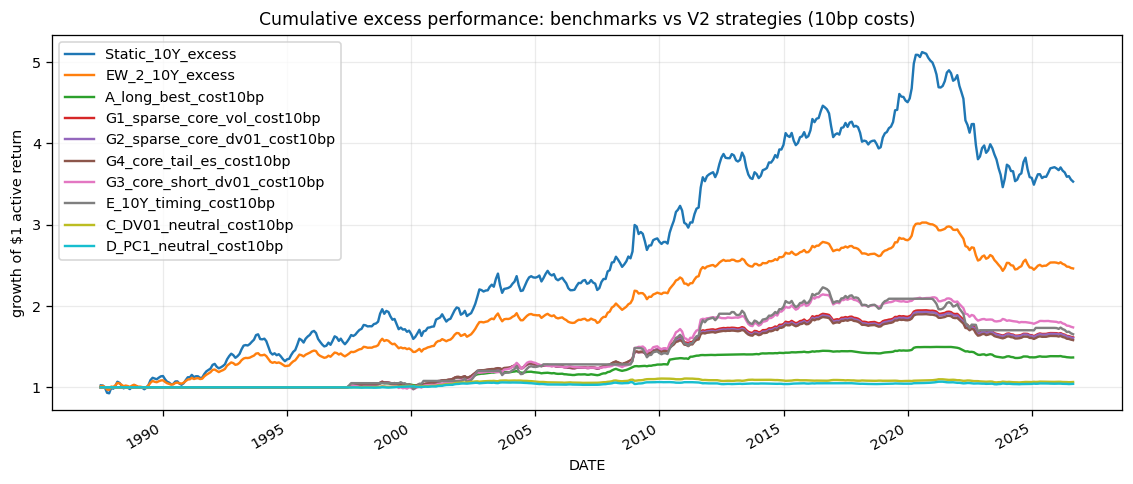

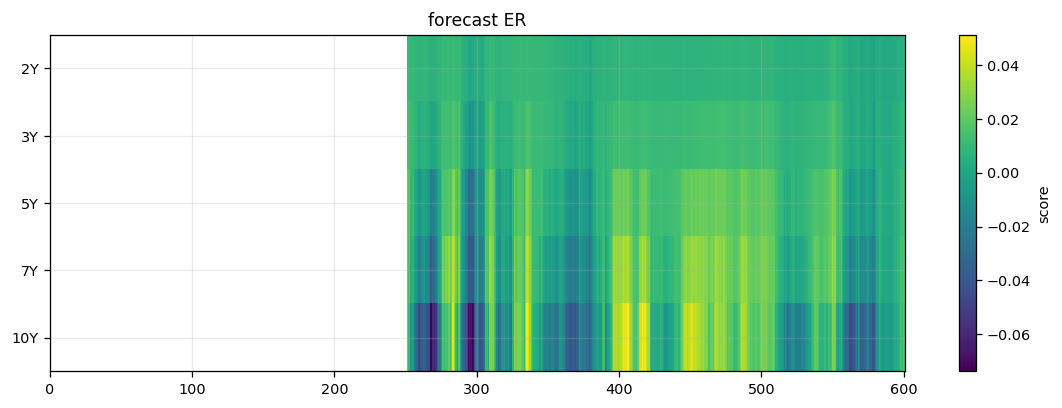

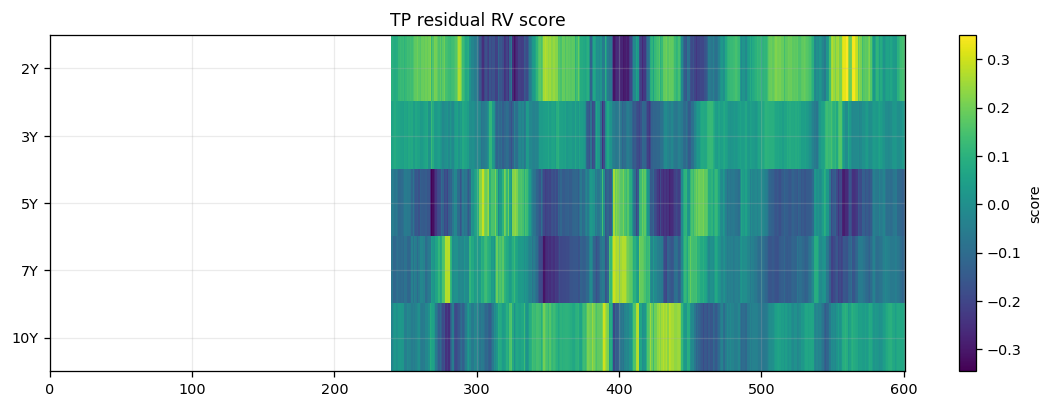

Average weights


,2,3,5,7,10
A_long_best,0.7360,0.0000,0.0000,0.0000,0.0060
B_top_bottom,0.3700,-0.0160,-0.0090,-0.0010,-0.3450
C_DV01_neutral,0.6090,-0.0150,-0.0050,-0.0000,-0.1140
D_PC1_neutral,0.3430,0.1320,0.0380,0.0050,-0.1300
G1_sparse_core_vol,0.3000,0.1950,0.0630,0.1040,0.0800
G2_sparse_core_dv01,0.2960,0.1980,0.0650,0.1040,0.0800
G3_core_short_dv01,0.2350,0.1740,0.1400,0.2580,-0.0640
G4_core_tail_es,0.3260,0.1790,0.0620,0.0940,0.0820
R1_resid_top2_bottom2,0.0810,-0.0120,-0.0760,-0.0570,0.0630
R2_resid_carry_dv01,0.0750,0.0400,-0.0620,-0.0520,0.0400


In [15]:

# ===== 14. Plots: cumulative performance, average weights, score heatmaps =====
eval_start = dates[MINW + H]
# Plot benchmarks + best strategy variants at 10bp costs.
plot_names = ["Static_10Y_excess", "EW_2_10Y_excess"]
perf10 = perf[perf.index.str.endswith("cost10bp")].copy()
if not perf10.empty and "Sharpe" in perf10.columns:
    plot_names += perf10.sort_values("Sharpe", ascending=False).head(8).index.tolist()
ret_plot = pd.DataFrame({nm: all_returns[nm] for nm in plot_names if nm in all_returns}).loc[eval_start:].dropna(how="all")
wealth = (1 + ret_plot.fillna(0)).cumprod()
wealth.plot(figsize=(12, 4.8), title="Cumulative excess performance: benchmarks vs V2 strategies (10bp costs)")
plt.ylabel("growth of $1 active return")
plt.show()

# Score heatmaps
for nm, sdf in [("forecast ER", forecast_er[TENORS]), ("TP residual RV score", rv_score[TENORS])]:
    plt.figure(figsize=(12, 3.8))
    plt.imshow(sdf.T, aspect="auto", interpolation="nearest", extent=[0, len(sdf)-1, len(TENORS)-0.5, -0.5])
    plt.yticks(range(len(TENORS)), [f"{n}Y" for n in TENORS])
    plt.title(nm)
    plt.colorbar(label="score")
    plt.show()

avgw = pd.DataFrame({name: w.loc[eval_start:].mean() for name, w in W_used.items()}).T
avgw.to_csv(OUT_DIR / "v2_average_weights.csv")
print("Average weights")
display(avgw.round(3))



## V2 verdict template

Use the output tables after running the notebook.

### Branch A: sparse greedy curve allocator

- If `G1_sparse_core_vol` or `G2_sparse_core_dv01` improves over `E_10Y_timing` with reasonable turnover and no excessive 10Y beta:
  > The MacroAnchor signal can be upgraded from a 10Y predictor to a sparse tenor-allocation framework.

- If `G3_core_short_dv01` improves drawdowns/risk but not returns:
  > Short legs are useful as hedges, not as standalone RV alpha.

- If `G4_core_tail_es` is the only branch that works:
  > The signal is best framed as risk-budgeted duration allocation under tail constraints.

### Branch B: residualized/carry-aware RV

- If `R2/R3` generate positive, cost-resistant returns with low beta to 10Y and a meaningful NW t-stat:
  > The term-premium surface contains curve-relative information beyond duration timing.

- If `R2/R3` are small/insignificant but low-beta:
  > The construction is orthogonal to duration, but economic value is not yet established.

- If both branches fail:
  > Keep the V2 as an honest negative extension; the paper core remains the 10Y bond-risk-premium / specification-audit result.


In [16]:

# ===== 15. Export compact V2 audit bundle =====
score.to_csv(OUT_DIR / "v2_score_base.csv")
rv_score.to_csv(OUT_DIR / "v2_score_residualized_carry.csv")
tp_df[TENORS].to_csv(OUT_DIR / "v2_tp_hw.csv")
forecast_er.to_csv(OUT_DIR / "v2_forecast_er.csv")
forecast_vol.to_csv(OUT_DIR / "v2_forecast_vol.csv")
RX12[TENORS].to_csv(OUT_DIR / "v2_rx12_exact.csv")
ret_excess[TENORS].to_csv(OUT_DIR / "v2_monthly_excess_returns.csv")
perf.to_csv(OUT_DIR / "v2_performance.csv")
expo.to_csv(OUT_DIR / "v2_exposure_diagnostics.csv")
attr_summary.to_csv(OUT_DIR / "v2_attribution_10bp.csv")
for name, w in W_used.items():
    w.to_csv(OUT_DIR / f"weights_{name}.csv")
print(f"Exported V2 outputs to: {OUT_DIR.resolve()}")


Exported V2 outputs to: /content/macroanchor_curve_rv_v3_outputs


## V3 extension: dynamic transaction costs and implementation controls

V2 showed that the sparse/greedy allocator was promising but potentially cost- and turnover-sensitive, especially for the core-plus-short-hedge variant. V3 therefore adds two controls before changing the economic story:

- empirical/dynamic cost estimates from liquid Treasury ETF OHLC proxies via Corwin--Schultz high--low spreads;
- turnover controls: smoothing, no-trade bands, quarterly rebalancing and a simple implementation hurdle.

The point is not to optimize the strategy into existence. The point is to test whether the V2 sparse allocation survives more realistic implementation assumptions.


In [17]:

# ===== 16. V3 transaction-cost layer: Corwin--Schultz ETF-proxy spread estimator =====
# Transaction-cost principle:
# - Corwin--Schultz estimates a full bid-ask spread from high-low ranges.
# - Strategy turnover is one-way notional turnover, so we charge half the estimated spread per traded notional.
# - Treasury constant-maturity series do not contain OHLC or quotes, so V3 uses liquid ETF proxies when available.
# - Fixed-bps grids are retained as sensitivity checks, not as the main cost model.

TC_COST_MODE = "corwin_schultz_etf_proxy"  # fallback: fixed_bps_by_tenor if yfinance/OHLC unavailable
TC_ROLLING_MONTHS = 12
TC_MIN_ONEWAY_BPS = 0.25
TC_MAX_ONEWAY_BPS = 25.0
TC_PROXY_TICKERS = {2: "SHY", 3: "SHY", 5: "IEI", 7: "IEF", 10: "IEF"}
TC_FIXED_ONEWAY_BPS = {2: 2.0, 3: 2.0, 5: 3.0, 7: 4.0, 10: 4.0}


def corwin_schultz_full_spread(high, low):
    """Corwin--Schultz full relative spread from daily high/low prices.

    Returns a daily full-spread estimate in relative units. Negative alphas are clipped to zero;
    the output is winsorized later. This is used on ETF OHLC proxies, not on raw yield series.
    """
    high = pd.Series(high).astype(float)
    low = pd.Series(low).astype(float)
    valid = (high > 0) & (low > 0) & np.isfinite(high) & np.isfinite(low)
    high = high.where(valid)
    low = low.where(valid)

    log_hl = np.log(high / low)
    beta = log_hl.pow(2).rolling(2).sum()
    high_2d = pd.concat([high, high.shift(1)], axis=1).max(axis=1)
    low_2d = pd.concat([low, low.shift(1)], axis=1).min(axis=1)
    gamma = np.log(high_2d / low_2d).pow(2)
    denom = 3 - 2*np.sqrt(2)
    alpha = ((np.sqrt(2*beta) - np.sqrt(beta)) / denom) - np.sqrt(gamma / denom)
    alpha = alpha.replace([np.inf, -np.inf], np.nan).clip(lower=0)
    full_spread = 2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha))
    return full_spread.replace([np.inf, -np.inf], np.nan).clip(lower=0, upper=0.10)


def fetch_yfinance_ohlc(ticker, start=START, end=END):
    """Fetch daily OHLC with yfinance; returns None if unavailable."""
    try:
        import yfinance as yf
    except Exception as e:
        warnings.warn(f"yfinance unavailable; cannot estimate CS costs from ETF OHLC. Error: {e}")
        return None
    try:
        df = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False, threads=False)
        if df is None or df.empty:
            return None
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        cols = [c for c in ["Open", "High", "Low", "Close", "Adj Close"] if c in df.columns]
        df = df[cols].copy()
        df.index = pd.to_datetime(df.index)
        return df
    except Exception as e:
        warnings.warn(f"Could not fetch {ticker} OHLC from yfinance. Error: {e}")
        return None


def build_corwin_schultz_cost_bps(index, tenors=TENORS, proxy_map=TC_PROXY_TICKERS):
    """Build monthly one-way cost bps by tenor from ETF OHLC proxies.

    The mapped ETF's daily CS full-spread is converted to one-way bps = 0.5 * full spread * 10,000.
    Monthly costs use a rolling median to reduce noise and are forward-filled to strategy dates.
    """
    unique_tickers = sorted(set(proxy_map.values()))
    ticker_monthly = {}
    for tic in unique_tickers:
        ohlc = fetch_yfinance_ohlc(tic, start=str(pd.Timestamp(index.min()).date()), end=str(pd.Timestamp(index.max()).date()))
        if ohlc is None or not {"High", "Low"}.issubset(ohlc.columns):
            continue
        full_spread = corwin_schultz_full_spread(ohlc["High"], ohlc["Low"])
        oneway_bps_daily = 0.5 * full_spread * 10000.0
        oneway_bps_monthly = oneway_bps_daily.resample("ME").median()
        oneway_bps_monthly = oneway_bps_monthly.rolling(TC_ROLLING_MONTHS, min_periods=3).median()
        oneway_bps_monthly = oneway_bps_monthly.clip(lower=TC_MIN_ONEWAY_BPS, upper=TC_MAX_ONEWAY_BPS)
        ticker_monthly[tic] = oneway_bps_monthly

    if not ticker_monthly:
        return None

    cost = pd.DataFrame(index=index, columns=tenors, dtype=float)
    for n in tenors:
        tic = proxy_map[n]
        if tic in ticker_monthly:
            cost[n] = ticker_monthly[tic].reindex(index).ffill().bfill()
    if cost.dropna(how="all").empty:
        return None
    return cost.ffill().bfill().clip(lower=TC_MIN_ONEWAY_BPS, upper=TC_MAX_ONEWAY_BPS)


def fixed_cost_bps_df(index, tenors=TENORS, fixed_map=TC_FIXED_ONEWAY_BPS):
    return pd.DataFrame({n: fixed_map.get(n, np.nan) for n in tenors}, index=index).astype(float)

# Build default V3 cost matrix.
try:
    dynamic_cost_bps = build_corwin_schultz_cost_bps(dates, TENORS)
except Exception as e:
    warnings.warn(f"CS cost builder failed; using fixed tenor bps fallback. Error: {e}")
    dynamic_cost_bps = None

if dynamic_cost_bps is None or dynamic_cost_bps.dropna(how="all").empty:
    COST_SOURCE = "fixed_bps_by_tenor_fallback"
    dynamic_cost_bps = fixed_cost_bps_df(dates, TENORS)
else:
    COST_SOURCE = "corwin_schultz_etf_proxy_half_spread"

print("V3 cost source:", COST_SOURCE)
print("One-way cost bps by tenor, latest:")
display(dynamic_cost_bps.tail(3))
print("Average one-way cost bps in evaluation window:")
display(dynamic_cost_bps.loc[dates[MINW+H]:].mean().to_frame("avg_oneway_bps").T.round(3))

dynamic_cost_bps.to_csv(OUT_DIR / "v3_dynamic_oneway_cost_bps_by_tenor.csv")


V3 cost source: corwin_schultz_etf_proxy_half_spread
One-way cost bps by tenor, latest:


,2,3,5,7,10
DATE,,,,,
2026-06-30,0.2500,0.2500,0.2500,0.2500,0.2500
2026-07-31,0.2500,0.2500,0.2500,0.2500,0.2500
2026-08-31,0.2500,0.2500,0.2500,0.2500,0.2500


Average one-way cost bps in evaluation window:


,2,3,5,7,10
avg_oneway_bps,0.2790,0.2790,0.2500,0.2500,0.2500


In [18]:
# ===== 17. V3 turnover controls and cost-aware implementation wrappers =====

def quarterly_rebalance_targets(W_in):
    """Keep target weights fixed within calendar quarters using the first available month of each quarter."""
    W = W_in.copy().astype(float)

    # Robust quarter labels
    idx = pd.to_datetime(W.index)
    q = pd.Series(idx.to_period("Q"), index=W.index)

    # First available observation of each quarter
    is_reb = q.ne(q.shift()).values

    # Build target DataFrame explicitly to avoid DataFrame.where shape errors
    target = pd.DataFrame(np.nan, index=W.index, columns=W.columns, dtype=float)
    target.iloc[is_reb, :] = W.iloc[is_reb, :].values

    return target.ffill().fillna(0.0)


def _row_reindex_or_default(df, dt, cols, default_value=5.0):
    """Return df row at dt reindexed to cols, with robust fallback."""
    if df is None or len(df) == 0:
        return pd.Series(default_value, index=cols, dtype=float)

    if dt in df.index:
        row = df.reindex(columns=cols).loc[dt].astype(float)
    else:
        row = pd.Series(np.nan, index=cols, dtype=float)

    vals = row.values.astype(float)
    if np.isfinite(vals).any():
        fill_val = np.nanmedian(vals[np.isfinite(vals)])
    else:
        fill_val = default_value

    return row.fillna(fill_val).astype(float)


def apply_cost_hurdle(W_target, cost_bps_df, hurdle_mult=1.25, alpha=1.0, no_trade_band=0.02):
    """Implementation-hurdle wrapper around a target strategy.

    A rebalance is accepted only if the expected 12m return improvement versus current holdings
    exceeds a multiple of the one-way estimated trading cost. Accepted trades can be partially
    implemented through alpha smoothing. This is deliberately simple and transparent.
    """
    W = W_target.copy().astype(float)
    out = pd.DataFrame(0.0, index=W.index, columns=W.columns)

    prev = np.zeros(W.shape[1], dtype=float)
    cols = list(W.columns)

    for i, dt in enumerate(W.index):
        target = W.iloc[i].values.astype(float)
        delta = target - prev

        # No-trade band on total absolute weight change
        if np.nansum(np.abs(delta)) < no_trade_band:
            out.iloc[i, :] = prev
            continue

        # Expected 12m return forecast, aligned to current strategy columns
        if dt in forecast_er.index:
            mu = forecast_er.reindex(columns=cols).loc[dt].astype(float).values
        else:
            mu = np.full(len(cols), np.nan)

        if not np.isfinite(mu).any():
            out.iloc[i, :] = prev
            continue

        # Dynamic one-way cost in bps, aligned to current strategy columns
        cbps = _row_reindex_or_default(cost_bps_df, dt, cols, default_value=5.0).values
        cbps = np.where(np.isfinite(cbps), cbps, 5.0)

        one_way_cost = float(np.nansum(np.abs(delta) * cbps / 10000.0))
        er_gain_12m = float(np.nansum(delta * mu))

        # Implementation hurdle: accept trade only if expected return gain clears estimated trading cost
        if er_gain_12m >= hurdle_mult * one_way_cost:
            new = (1.0 - alpha) * prev + alpha * target
        else:
            new = prev

        out.iloc[i, :] = new
        prev = new

    return out


def build_v3_weight_variants(base_weights_dict):
    variants = {}

    for name, W0 in base_weights_dict.items():
        if not name.startswith("G"):
            continue

        W0 = W0.copy().astype(float)

        # Smooth monthly implementation: directly addresses the V2 turnover problem.
        variants[f"V3_{name}_smooth_a035_b05"] = smooth_weights(
            W0, alpha=0.35, no_trade_band=0.05
        )

        # Quarterly rebalance: coarse implementation schedule, no look-ahead.
        Wq = quarterly_rebalance_targets(W0)
        variants[f"V3_{name}_quarterly"] = Wq

        # Quarterly + smoothing: more institutional implementation.
        variants[f"V3_{name}_quarterly_smooth"] = smooth_weights(
            Wq, alpha=0.50, no_trade_band=0.03
        )

        # Cost hurdle: only rebalance if expected return gain clears estimated cost.
        variants[f"V3_{name}_cost_hurdle"] = apply_cost_hurdle(
            W0,
            dynamic_cost_bps,
            hurdle_mult=1.25,
            alpha=0.75,
            no_trade_band=0.03
        )

    return variants


V3_WEIGHTS = build_v3_weight_variants(G_WEIGHTS)

print("Constructed V3 variants:", len(V3_WEIGHTS))

eval_start = dates[MINW + H] if "dates" in globals() else None

for k, w in V3_WEIGHTS.items():
    if eval_start is not None:
        w_eval = w.loc[eval_start:]
    else:
        w_eval = w

    avg_gross = w.abs().sum(axis=1).replace(0, np.nan).mean()
    avg_net = w.sum(axis=1).replace(0, np.nan).mean()
    ann_turnover = w_eval.diff().abs().sum(axis=1).mean() * 12

    print(
        k,
        "avg gross", round(float(avg_gross), 3),
        "avg net", round(float(avg_net), 3),
        "ann turnover", round(float(ann_turnover), 3)
    )

Constructed V3 variants: 16
V3_G1_sparse_core_vol_smooth_a035_b05 avg gross 0.989 avg net 0.989 ann turnover 1.354
V3_G1_sparse_core_vol_quarterly avg gross 1.0 avg net 1.0 ann turnover 1.437
V3_G1_sparse_core_vol_quarterly_smooth avg gross 0.997 avg net 0.997 ann turnover 1.325
V3_G1_sparse_core_vol_cost_hurdle avg gross 0.993 avg net 0.993 ann turnover 1.648
V3_G2_sparse_core_dv01_smooth_a035_b05 avg gross 0.989 avg net 0.989 ann turnover 1.353
V3_G2_sparse_core_dv01_quarterly avg gross 1.0 avg net 1.0 ann turnover 1.455
V3_G2_sparse_core_dv01_quarterly_smooth avg gross 0.997 avg net 0.997 ann turnover 1.343
V3_G2_sparse_core_dv01_cost_hurdle avg gross 0.993 avg net 0.993 ann turnover 1.65
V3_G3_core_short_dv01_smooth_a035_b05 avg gross 1.642 avg net 0.989 ann turnover 3.403
V3_G3_core_short_dv01_quarterly avg gross 1.734 avg net 1.0 ann turnover 3.569
V3_G3_core_short_dv01_quarterly_smooth avg gross 1.682 avg net 0.997 ann turnover 3.278
V3_G3_core_short_dv01_cost_hurdle avg gross 1

In [19]:

# ===== 18. V3 dynamic-cost backtest and comparison with V2 baselines =====
def strategy_returns_dynamic_cost(weights, ret_excess_df, cost_bps_df):
    Wlag = lag_weights(weights)
    gross_ret = (Wlag * ret_excess_df[weights.columns]).sum(axis=1)
    turnover_by_tenor = weights.diff().abs().fillna(weights.abs())
    cbps = cost_bps_df.reindex(weights.index).ffill().bfill()[weights.columns]
    cost = (turnover_by_tenor * (cbps / 10000.0)).sum(axis=1)
    turnover = turnover_by_tenor.sum(axis=1)
    return gross_ret - cost, gross_ret, cost, turnover

# Build a common comparison set: V2 Track A, V3 controlled versions, and key benchmarks.
compare_weights = {}
for k in ["G1_sparse_core_vol", "G2_sparse_core_dv01", "G3_core_short_dv01", "G4_core_tail_es", "E_10Y_timing"]:
    if k in W_used:
        compare_weights[k] = W_used[k]
compare_weights.update(V3_WEIGHTS)

v3_rows = []
v3_returns = {}
v3_turnover = {}
for name, bret in bench.items():
    r_eval = bret.loc[dates[MINW+H:]]
    row = perf_stats(r_eval, name=name)
    row["cost_model"] = "none"
    v3_rows.append(row)
    v3_returns[name] = bret

for name, weights in compare_weights.items():
    r_net, r_gross, cost, to = strategy_returns_dynamic_cost(weights, ret_excess, dynamic_cost_bps)
    nm = f"{name}_dynamicTC"
    row = perf_stats(r_net.loc[dates[MINW+H:]], turnover=to.loc[dates[MINW+H:]], name=nm)
    row["cost_model"] = COST_SOURCE
    row["avg_cost_bps_ann"] = cost.loc[dates[MINW+H:]].mean()*12*10000
    v3_rows.append(row)
    v3_returns[nm] = r_net
    v3_turnover[nm] = to

# Add 10bp fixed-cost table for direct comparability with V2.
for name, weights in compare_weights.items():
    r_net, r_gross, cost, to = strategy_returns(weights, ret_excess, cost_bps=10.0)
    nm = f"{name}_fixed10bp"
    row = perf_stats(r_net.loc[dates[MINW+H:]], turnover=to.loc[dates[MINW+H:]], name=nm)
    row["cost_model"] = "fixed_10bp_oneway"
    row["avg_cost_bps_ann"] = cost.loc[dates[MINW+H:]].mean()*12*10000
    v3_rows.append(row)

v3_perf = pd.DataFrame(v3_rows).set_index("name")
cols_order = [c for c in ["cost_model", "n", "ann_ret", "ann_vol", "Sharpe", "MaxDD", "hit_rate", "ann_turnover", "avg_cost_bps_ann"] if c in v3_perf.columns]
v3_perf = v3_perf[cols_order]
v3_perf.to_csv(OUT_DIR / "v3_performance_dynamic_and_fixed_costs.csv")
print("V3 performance table: sorted by Sharpe")
display(v3_perf.sort_values("Sharpe", ascending=False).head(40))


V3 performance table: sorted by Sharpe


,cost_model,n,ann_ret,ann_vol,Sharpe,MaxDD,hit_rate,ann_turnover,avg_cost_bps_ann
name,,,,,,,,,
V3_G1_sparse_core_vol_cost_hurdle_dynamicTC,corwin_schultz_etf_proxy_half_spread,470,0.0178,0.0309,0.5764,-0.1468,0.4468,1.6480,0.4468
V3_G3_core_short_dv01_smooth_a035_b05_dynamicTC,corwin_schultz_etf_proxy_half_spread,470,0.0196,0.0340,0.5752,-0.1342,0.4447,3.4031,0.9240
V3_G4_core_tail_es_cost_hurdle_dynamicTC,corwin_schultz_etf_proxy_half_spread,470,0.0168,0.0292,0.5746,-0.1468,0.4468,1.6831,0.4570
V3_G3_core_short_dv01_cost_hurdle_dynamicTC,corwin_schultz_etf_proxy_half_spread,470,0.0216,0.0380,0.5685,-0.1331,0.4468,3.4624,0.8834
V3_G2_sparse_core_dv01_cost_hurdle_dynamicTC,corwin_schultz_etf_proxy_half_spread,470,0.0176,0.0310,0.5665,-0.1537,0.4468,1.6497,0.4472
V3_G4_core_tail_es_quarterly_dynamicTC,corwin_schultz_etf_proxy_half_spread,470,0.0150,0.0264,0.5657,-0.1374,0.4404,1.4498,0.4088
V3_G1_sparse_core_vol_quarterly_dynamicTC,corwin_schultz_etf_proxy_half_spread,470,0.0155,0.0274,0.5638,-0.1435,0.4404,1.4372,0.4059
V3_G3_core_short_dv01_quarterly_smooth_dynamicTC,corwin_schultz_etf_proxy_half_spread,470,0.0196,0.0348,0.5630,-0.1310,0.4447,3.2782,0.9386
V3_G3_core_short_dv01_quarterly_dynamicTC,corwin_schultz_etf_proxy_half_spread,470,0.0200,0.0355,0.5628,-0.1334,0.4468,3.5694,1.0101


In [20]:

# ===== 19. V3 statistical and exposure diagnostics =====
v3_stat_rows = []
eval_start = dates[MINW + H]
for nm, rser in v3_returns.items():
    if ("V3_" in nm) or ("G1_" in nm) or ("G2_" in nm) or ("G3_" in nm) or ("G4_" in nm) or ("E_10Y" in nm):
        ann_mean, nw_t = nw_mean_tstat(rser.loc[eval_start:], lag=12)
        v3_stat_rows.append({"strategy": nm, "ann_mean": ann_mean, "NW_t_mean": nw_t})
v3_mean_tests = pd.DataFrame(v3_stat_rows).set_index("strategy").sort_values("NW_t_mean", ascending=False)
v3_mean_tests.to_csv(OUT_DIR / "v3_strategy_mean_nw_tests.csv")
print("V3 mean-return Newey-West tests")
display(v3_mean_tests.head(40))

# Exposure diagnostics for V3 strategies, same definitions as V2.
v3_expo_rows = []
static10 = ret_excess[10].loc[eval_start:]
Dvec = pd.Series(TENORS, index=TENORS, dtype=float)
for name, weights in compare_weights.items():
    Wlag = lag_weights(weights)
    avg_net = Wlag.sum(1).loc[eval_start:].mean()
    avg_gross = Wlag.abs().sum(1).loc[eval_start:].mean()
    avg_dur = (Wlag * Dvec).sum(1).loc[eval_start:].mean()
    r0, _, _, to = strategy_returns_dynamic_cost(weights, ret_excess, dynamic_cost_bps)
    r_eval = r0.loc[eval_start:]
    a10, b10, r2_10 = ols_beta_alpha(r_eval, static10)
    v3_expo_rows.append({
        "strategy": name,
        "avg_net_$": avg_net,
        "avg_gross_$": avg_gross,
        "avg_duration_exposure": avg_dur,
        "ann_turnover": to.loc[eval_start:].mean()*12,
        "alpha_vs_10Y_ann": a10,
        "beta_vs_10Y": b10,
        "R2_vs_10Y": r2_10,
    })
v3_expo = pd.DataFrame(v3_expo_rows).set_index("strategy")
v3_expo.to_csv(OUT_DIR / "v3_exposure_diagnostics_dynamic_costs.csv")
print("V3 exposure diagnostics")
display(v3_expo.loc[[idx for idx in v3_expo.index if idx.startswith("V3_")]].sort_values("ann_turnover").head(30))


V3 mean-return Newey-West tests


,ann_mean,NW_t_mean
strategy,,
V3_G3_core_short_dv01_cost_hurdle_dynamicTC,0.0216,2.7735
V3_G3_core_short_dv01_quarterly_dynamicTC,0.0200,2.7374
V3_G3_core_short_dv01_quarterly_smooth_dynamicTC,0.0196,2.7057
V3_G3_core_short_dv01_smooth_a035_b05_dynamicTC,0.0196,2.7050
G3_core_short_dv01_dynamicTC,0.0207,2.6094
V3_G1_sparse_core_vol_cost_hurdle_dynamicTC,0.0178,2.5910
V3_G4_core_tail_es_cost_hurdle_dynamicTC,0.0168,2.5732
V3_G2_sparse_core_dv01_cost_hurdle_dynamicTC,0.0176,2.5303
V3_G4_core_tail_es_quarterly_dynamicTC,0.0150,2.4930


V3 exposure diagnostics


,avg_net_$,avg_gross_$,avg_duration_exposure,ann_turnover,alpha_vs_10Y_ann,beta_vs_10Y,R2_vs_10Y
strategy,,,,,,,
V3_G4_core_tail_es_quarterly_smooth,0.7383,0.7383,2.9298,1.3228,0.0059,0.2445,0.5150
V3_G1_sparse_core_vol_quarterly_smooth,0.7383,0.7383,2.9973,1.3251,0.0064,0.2520,0.5045
V3_G2_sparse_core_dv01_quarterly_smooth,0.7383,0.7383,2.9935,1.3430,0.0057,0.2517,0.5091
V3_G2_sparse_core_dv01_smooth_a035_b05,0.7364,0.7364,3.0026,1.3527,0.0058,0.2532,0.5330
V3_G1_sparse_core_vol_smooth_a035_b05,0.7364,0.7364,2.9968,1.3538,0.0060,0.2529,0.5304
V3_G4_core_tail_es_smooth_a035_b05,0.7364,0.7364,2.9431,1.3939,0.0056,0.2475,0.5402
V3_G1_sparse_core_vol_quarterly,0.7404,0.7404,3.0064,1.4372,0.0067,0.2497,0.5010
V3_G4_core_tail_es_quarterly,0.7404,0.7404,2.9386,1.4498,0.0064,0.2430,0.5105
V3_G2_sparse_core_dv01_quarterly,0.7404,0.7404,3.0021,1.4551,0.0059,0.2489,0.5066


## Spanning regressions: does sparse allocation add value beyond its building blocks?

This section adds three **pre-specified diagnostic regressions** for every V3 controlled sparse allocator under the dynamic transaction-cost model:

1. **Parent-signal spanning:** sparse allocator returns on the cost-aware 10Y timing strategy. This tests whether portfolio construction adds value beyond the simplest implementation of the same macro-anchor signal.
2. **Eligible-tenor spanning:** sparse allocator returns on a static linear span of the same 2Y, 3Y, 5Y, 7Y and 10Y excess-return series available to the allocator. This tests whether the dynamic allocation rule adds value beyond static exposures to its own opportunity set.
3. **Curve-factor spanning:** sparse allocator returns on fixed Level, Slope and Curvature factor-mimicking portfolios. The factor loadings are estimated **once using only the pre-evaluation yield-change sample**, then held fixed in the evaluation period.

The intercept is the incremental return not spanned by the benchmark set. Inference uses Newey--West/HAC standard errors with a 12-month lag. The eligible-tenor regression also reports the standardized-regressor condition number because Treasury tenor returns are highly collinear; individual tenor betas should therefore not be over-interpreted.

The deliberately omitted specification is the joint `10Y timing + tenor returns` regression: it is not part of this test suite.


In [21]:
# ===== 20. Spanning regressions: parent signal, tenor space, curve factors =====
# Three deliberately separate questions. No joint 10Y-timing + tenor-return regression.

SPANNING_NW_LAG = 12
SPANNING_MIN_OBS = 60


def nw_ols(y, X, lag=SPANNING_NW_LAG, min_obs=SPANNING_MIN_OBS):
    """OLS with Bartlett/Newey-West HAC covariance.

    Parameters
    ----------
    y : Series
        Dependent return series.
    X : Series or DataFrame
        Regressors. A constant is added internally.
    lag : int
        HAC truncation lag in monthly observations.

    Returns
    -------
    dict with coefficients, HAC t-stats, annualized alpha, R2, n, rank,
    and a standardized-regressor condition number.
    """
    y = pd.Series(y, name="y").astype(float)
    if isinstance(X, pd.Series):
        X = X.to_frame()
    X = pd.DataFrame(X).astype(float)

    df = pd.concat([y, X], axis=1).replace([np.inf, -np.inf], np.nan).dropna()
    if len(df) < min_obs:
        return None

    yv = df.iloc[:, 0].to_numpy(float)
    Xraw = df.iloc[:, 1:].to_numpy(float)
    names = list(df.columns[1:])

    # Drop numerically constant regressors before estimation.
    std = np.nanstd(Xraw, axis=0, ddof=1)
    keep = np.isfinite(std) & (std > 1e-12)
    Xraw = Xraw[:, keep]
    names = [n for n, k in zip(names, keep) if k]
    if Xraw.shape[1] == 0:
        return None

    Z = np.column_stack([np.ones(len(df)), Xraw])
    rank = int(np.linalg.matrix_rank(Z))
    if rank < Z.shape[1]:
        # pinv keeps the diagnostic available even if the raw tenor span is near-singular.
        bread = np.linalg.pinv(Z.T @ Z)
    else:
        bread = np.linalg.inv(Z.T @ Z)

    beta = bread @ Z.T @ yv
    resid = yv - Z @ beta

    # Newey-West meat using raw (not 1/T-scaled) moment sums.
    meat = np.zeros((Z.shape[1], Z.shape[1]), dtype=float)
    for t in range(len(df)):
        zt = Z[t][:, None]
        meat += (resid[t] ** 2) * (zt @ zt.T)

    L = int(min(max(lag, 0), len(df) - 1))
    for ell in range(1, L + 1):
        w = 1.0 - ell / (L + 1.0)
        G = np.zeros_like(meat)
        for t in range(ell, len(df)):
            zt = Z[t][:, None]
            zl = Z[t - ell][:, None]
            G += resid[t] * resid[t - ell] * (zt @ zl.T)
        meat += w * (G + G.T)

    cov = bread @ meat @ bread
    se = np.sqrt(np.clip(np.diag(cov), 0.0, np.inf))
    tstat = np.divide(beta, se, out=np.full_like(beta, np.nan), where=se > 0)

    sst = float(np.sum((yv - yv.mean()) ** 2))
    sse = float(np.sum(resid ** 2))
    r2 = np.nan if sst <= 0 else 1.0 - sse / sst

    # Condition number on standardized regressors only (intercept excluded).
    Xstd = (Xraw - Xraw.mean(axis=0)) / Xraw.std(axis=0, ddof=1)
    cond = float(np.linalg.cond(Xstd)) if Xstd.shape[1] > 1 else 1.0

    coef = pd.Series(beta, index=["const"] + names)
    tvals = pd.Series(tstat, index=["const"] + names)
    ses = pd.Series(se, index=["const"] + names)

    return {
        "n": int(len(df)),
        "rank": rank,
        "condition_number": cond,
        "R2": float(r2),
        "alpha_monthly": float(coef["const"]),
        "alpha_ann": float(coef["const"] * 12.0),
        "alpha_se_ann": float(ses["const"] * 12.0),
        "alpha_t_NW": float(tvals["const"]),
        "coef": coef,
        "t_NW": tvals,
    }


# ---- Fixed Level / Slope / Curvature factor-mimicking portfolios ----
# Estimate the curve PCA only on data available before the evaluation sample.
_pre_eval_dy = DY_TENOR.loc[:eval_start].iloc[:-1].dropna(how="any")
if len(_pre_eval_dy) < 60:
    raise RuntimeError("Insufficient pre-evaluation history to estimate fixed curve-factor loadings.")

_cov_dy = np.cov(_pre_eval_dy[TENORS].values, rowvar=False)
_eval, _evec = np.linalg.eigh(_cov_dy)
_order = np.argsort(_eval)[::-1]
_load = _evec[:, _order[:3]].copy()

# Deterministic sign conventions: level positive on average; slope positive long-end minus short-end;
# curvature positive in the belly relative to the wings.
if _load[:, 0].mean() < 0:
    _load[:, 0] *= -1
if (_load[-1, 1] - _load[0, 1]) < 0:
    _load[:, 1] *= -1
_belly_i = int(np.argmin(np.abs(np.asarray(TENORS, float) - 5.0)))
if (_load[_belly_i, 2] - 0.5 * (_load[0, 2] + _load[-1, 2])) < 0:
    _load[:, 2] *= -1

# Convert PCA loading directions into fixed gross-1 factor-mimicking portfolios.
_factor_weights = _load / np.maximum(np.abs(_load).sum(axis=0, keepdims=True), 1e-12)
curve_factor_loadings = pd.DataFrame(
    _factor_weights,
    index=TENORS,
    columns=["Level", "Slope", "Curvature"],
)
curve_factor_returns = pd.DataFrame(
    ret_excess[TENORS].values @ _factor_weights,
    index=ret_excess.index,
    columns=curve_factor_loadings.columns,
)
curve_factor_loadings.to_csv(OUT_DIR / "v3_spanning_curve_factor_loadings.csv")
curve_factor_returns.to_csv(OUT_DIR / "v3_spanning_curve_factor_returns.csv")

print("Fixed pre-evaluation curve-factor loadings (gross-1):")
display(curve_factor_loadings)


# ---- Sparse strategies to test ----
# V3 controlled implementations under the same dynamic transaction-cost model used in the headline results.
spanning_strategies = [
    nm for nm in v3_returns
    if nm.startswith("V3_") and nm.endswith("_dynamicTC")
]
if not spanning_strategies:
    raise RuntimeError("No V3 controlled dynamic-cost strategies found in v3_returns.")

parent_10y_name = "E_10Y_timing_dynamicTC"
if parent_10y_name not in v3_returns:
    raise RuntimeError(f"Required parent benchmark {parent_10y_name} not found in v3_returns.")

parent_10y = v3_returns[parent_10y_name].loc[eval_start:]
eligible_tenor_returns = ret_excess[TENORS].loc[eval_start:].copy()
eligible_tenor_returns.columns = [f"Tenor_{n}Y" for n in TENORS]
curve_factors_eval = curve_factor_returns.loc[eval_start:].copy()

span_rows = []
beta_rows = []


def _store_span(strategy, test_name, fit):
    if fit is None:
        return
    span_rows.append({
        "strategy": strategy,
        "test": test_name,
        "n": fit["n"],
        "rank": fit["rank"],
        "condition_number": fit["condition_number"],
        "alpha_ann": fit["alpha_ann"],
        "alpha_se_ann": fit["alpha_se_ann"],
        "alpha_t_NW": fit["alpha_t_NW"],
        "R2": fit["R2"],
    })
    for reg in fit["coef"].index:
        if reg == "const":
            continue
        beta_rows.append({
            "strategy": strategy,
            "test": test_name,
            "regressor": reg,
            "beta": float(fit["coef"].loc[reg]),
            "beta_t_NW": float(fit["t_NW"].loc[reg]),
        })


for nm in spanning_strategies:
    y = v3_returns[nm].loc[eval_start:]

    # 1) Parent-signal spanning: sparse allocator ~ 10Y timing.
    fit_parent = nw_ols(
        y,
        parent_10y.rename("E_10Y_timing"),
        lag=SPANNING_NW_LAG,
    )
    _store_span(nm, "parent_10Y_timing", fit_parent)

    # 2) Eligible-tenor spanning: sparse allocator ~ static linear span of 2/3/5/7/10Y returns.
    fit_tenors = nw_ols(
        y,
        eligible_tenor_returns,
        lag=SPANNING_NW_LAG,
    )
    _store_span(nm, "eligible_tenor_span", fit_tenors)

    # 3) Curve-factor spanning: sparse allocator ~ fixed Level/Slope/Curvature factor portfolios.
    fit_curve = nw_ols(
        y,
        curve_factors_eval,
        lag=SPANNING_NW_LAG,
    )
    _store_span(nm, "curve_factor_LSC", fit_curve)


spanning_summary = pd.DataFrame(span_rows).set_index(["strategy", "test"]).sort_index()
spanning_betas = pd.DataFrame(beta_rows).set_index(["strategy", "test", "regressor"]).sort_index()

spanning_summary.to_csv(OUT_DIR / "v3_spanning_summary.csv")
spanning_betas.to_csv(OUT_DIR / "v3_spanning_betas.csv")

print("Spanning summary: annualized alpha, Newey-West alpha t-stat, R2")
display(
    spanning_summary[["alpha_ann", "alpha_t_NW", "R2", "condition_number", "n"]]
    .sort_values(["test", "alpha_t_NW"], ascending=[True, False])
)

print("Spanning betas (HAC t-stats):")
display(spanning_betas)


# ---- Headline view: highest-Sharpe V3 controlled strategy ----
_v3_controlled_perf = v3_perf.loc[
    [i for i in v3_perf.index if i.startswith("V3_") and i.endswith("_dynamicTC")]
].copy()
headline_sparse = _v3_controlled_perf["Sharpe"].astype(float).idxmax()

print(f"Headline sparse allocator selected mechanically by highest dynamic-cost Sharpe: {headline_sparse}")
headline_spanning = spanning_summary.loc[headline_sparse].copy()
display(headline_spanning[["alpha_ann", "alpha_t_NW", "R2", "condition_number", "n"]])

print("Reading rules:")
print("1) parent_10Y_timing: positive HAC alpha => portfolio construction adds return beyond the parent 10Y timing implementation.")
print("2) eligible_tenor_span: positive HAC alpha => dynamic sparse allocation is not replicated by a static linear combination of eligible tenor returns.")
print("3) curve_factor_LSC: positive HAC alpha => performance is not fully explained by fixed Level/Slope/Curvature curve-factor exposures.")
print("4) High condition number in eligible_tenor_span is expected from Treasury-return collinearity; focus on alpha/R2, not individual tenor betas.")


Fixed pre-evaluation curve-factor loadings (gross-1):


,Level,Slope,Curvature
2,0.2427,-0.2935,0.0173
3,0.2218,-0.1297,-0.1933
5,0.1953,0.0865,0.3262
7,0.1778,0.2301,0.1474
10,0.1623,0.2601,-0.3158


Spanning summary: annualized alpha, Newey-West alpha t-stat, R2


,,alpha_ann,alpha_t_NW,R2,condition_number,n
strategy,test,,,,,
V3_G3_core_short_dv01_cost_hurdle_dynamicTC,curve_factor_LSC,0.0119,2.0531,0.4096,13.4639,470
V3_G3_core_short_dv01_smooth_a035_b05_dynamicTC,curve_factor_LSC,0.0101,1.8740,0.4075,13.4639,470
V3_G3_core_short_dv01_quarterly_dynamicTC,curve_factor_LSC,0.0104,1.8674,0.3541,13.4639,470
V3_G3_core_short_dv01_quarterly_smooth_dynamicTC,curve_factor_LSC,0.0099,1.7827,0.3567,13.4639,470
V3_G1_sparse_core_vol_cost_hurdle_dynamicTC,curve_factor_LSC,0.0075,1.6682,0.5606,13.4639,470
V3_G4_core_tail_es_cost_hurdle_dynamicTC,curve_factor_LSC,0.0066,1.5605,0.5737,13.4639,470
V3_G2_sparse_core_dv01_cost_hurdle_dynamicTC,curve_factor_LSC,0.0072,1.5591,0.5604,13.4639,470
V3_G4_core_tail_es_quarterly_dynamicTC,curve_factor_LSC,0.0050,1.3159,0.5564,13.4639,470
V3_G1_sparse_core_vol_quarterly_dynamicTC,curve_factor_LSC,0.0052,1.3131,0.5500,13.4639,470


Spanning betas (HAC t-stats):


beta  \
strategy                                     test                regressor              
V3_G1_sparse_core_vol_cost_hurdle_dynamicTC  curve_factor_LSC    Curvature     1.8773   
                                                                 Level        -0.4144   
                                                                 Slope         1.7396   
                                             eligible_tenor_span Tenor_10Y    -0.2110   
                                                                 Tenor_2Y     -0.6701   
...                                                                               ...   
V3_G4_core_tail_es_smooth_a035_b05_dynamicTC eligible_tenor_span Tenor_2Y     -0.5384   
                                                                 Tenor_3Y     -0.3152   
                                                                 Tenor_5Y      0.4891   
                                                                 Tenor_7Y      0.4937   
                                             parent_10Y_timing   E_10Y_timing  0.4527   

                                                                               beta_t_NW  
strategy                                     test                regressor                
V3_G1_sparse_core_vol_cost_hurdle_dynamicTC  curve_factor_LSC    Curvature        2.9282  
                                                                 Level           -1.3426  
                                                                 Slope            3.2281  
                                             eligible_tenor_span Tenor_10Y       -1.6253  
                                                                 Tenor_2Y        -1.1688  
...                                                                                  ...  
V3_G4_core_tail_es_smooth_a035_b05_dynamicTC eligible_tenor_span Tenor_2Y        -1.1621  
                                                                 Tenor_3Y        -0.7475  
                                                                 Tenor_5Y         1.8898  
                                                                 Tenor_7Y         2.8272  
                                             parent_10Y_timing   E_10Y_timing    13.0207  

[144 rows x 2 columns]

Headline sparse allocator selected mechanically by highest dynamic-cost Sharpe: V3_G1_sparse_core_vol_cost_hurdle_dynamicTC


,alpha_ann,alpha_t_NW,R2,condition_number,n
test,,,,,
curve_factor_LSC,0.0075,1.6682,0.5606,13.4639,470
eligible_tenor_span,0.0077,1.6079,0.5607,32.3143,470
parent_10Y_timing,0.0097,2.9069,0.7271,1.0000,470


Reading rules:
1) parent_10Y_timing: positive HAC alpha => portfolio construction adds return beyond the parent 10Y timing implementation.
2) eligible_tenor_span: positive HAC alpha => dynamic sparse allocation is not replicated by a static linear combination of eligible tenor returns.
3) curve_factor_LSC: positive HAC alpha => performance is not fully explained by fixed Level/Slope/Curvature curve-factor exposures.
4) High condition number in eligible_tenor_span is expected from Treasury-return collinearity; focus on alpha/R2, not individual tenor betas.


V3 dynamic-cost attribution


,carry_ann,roll_ann,repricing_ann,convexity_ann,funding_ann,cost_ann,total_ann
strategy,,,,,,,
V3_G3_core_short_dv01_cost_hurdle,0.0232,0.0044,0.0099,0.0004,-0.0162,-0.0001,0.0216
G3_core_short_dv01,0.0232,0.0043,0.0089,0.0005,-0.0161,-0.0002,0.0207
V3_G3_core_short_dv01_quarterly,0.0230,0.0042,0.0087,0.0003,-0.0161,-0.0001,0.0200
V3_G3_core_short_dv01_quarterly_smooth,0.0227,0.0042,0.0085,0.0003,-0.0159,-0.0001,0.0196
V3_G3_core_short_dv01_smooth_a035_b05,0.0227,0.0043,0.0081,0.0003,-0.0159,-0.0001,0.0196
V3_G1_sparse_core_vol_cost_hurdle,0.0224,0.0043,0.0066,0.0005,-0.0160,-0.0000,0.0178
V3_G2_sparse_core_dv01_cost_hurdle,0.0224,0.0043,0.0064,0.0006,-0.0160,-0.0000,0.0176
V3_G4_core_tail_es_cost_hurdle,0.0222,0.0042,0.0059,0.0005,-0.0160,-0.0000,0.0168
V3_G1_sparse_core_vol_quarterly,0.0220,0.0039,0.0052,0.0005,-0.0161,-0.0000,0.0155


Verdict candidates: dynamic cost only


,cost_model,n,ann_ret,ann_vol,Sharpe,MaxDD,hit_rate,ann_turnover,avg_cost_bps_ann,ann_mean,NW_t,variant_type
name,,,,,,,,,,,,
V3_G1_sparse_core_vol_cost_hurdle_dynamicTC,corwin_schultz_etf_proxy_half_spread,470,0.0178,0.0309,0.5764,-0.1468,0.4468,1.6480,0.4468,0.0178,2.5910,V3 controlled
V3_G3_core_short_dv01_smooth_a035_b05_dynamicTC,corwin_schultz_etf_proxy_half_spread,470,0.0196,0.0340,0.5752,-0.1342,0.4447,3.4031,0.9240,0.0196,2.7050,V3 controlled
V3_G4_core_tail_es_cost_hurdle_dynamicTC,corwin_schultz_etf_proxy_half_spread,470,0.0168,0.0292,0.5746,-0.1468,0.4468,1.6831,0.4570,0.0168,2.5732,V3 controlled
V3_G3_core_short_dv01_cost_hurdle_dynamicTC,corwin_schultz_etf_proxy_half_spread,470,0.0216,0.0380,0.5685,-0.1331,0.4468,3.4624,0.8834,0.0216,2.7735,V3 controlled
V3_G2_sparse_core_dv01_cost_hurdle_dynamicTC,corwin_schultz_etf_proxy_half_spread,470,0.0176,0.0310,0.5665,-0.1537,0.4468,1.6497,0.4472,0.0176,2.5303,V3 controlled
V3_G4_core_tail_es_quarterly_dynamicTC,corwin_schultz_etf_proxy_half_spread,470,0.0150,0.0264,0.5657,-0.1374,0.4404,1.4498,0.4088,0.0150,2.4930,V3 controlled
V3_G1_sparse_core_vol_quarterly_dynamicTC,corwin_schultz_etf_proxy_half_spread,470,0.0155,0.0274,0.5638,-0.1435,0.4404,1.4372,0.4059,0.0155,2.4850,V3 controlled
V3_G3_core_short_dv01_quarterly_smooth_dynamicTC,corwin_schultz_etf_proxy_half_spread,470,0.0196,0.0348,0.5630,-0.1310,0.4447,3.2782,0.9386,0.0196,2.7057,V3 controlled
V3_G3_core_short_dv01_quarterly_dynamicTC,corwin_schultz_etf_proxy_half_spread,470,0.0200,0.0355,0.5628,-0.1334,0.4468,3.5694,1.0101,0.0200,2.7374,V3 controlled


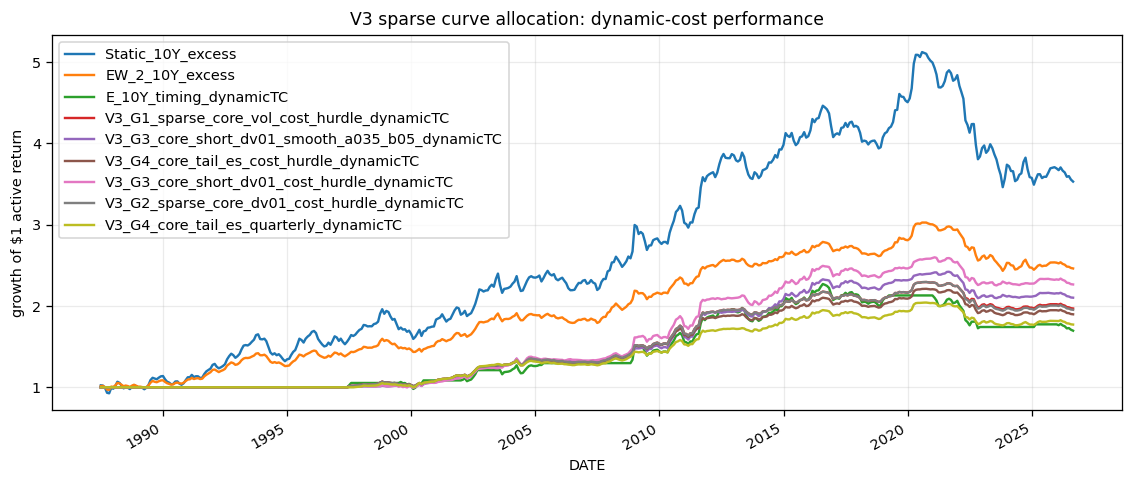

V3 reading rules:
1) If V3 controlled variants keep Sharpe/NW above E_10Y_timing after dynamic costs: sparse curve allocation is validated as an extension.
2) If only G3 works gross but collapses after dynamic costs: short-hedge version remains too implementation-sensitive.
3) If beta/R2 vs 10Y remain high: this is duration-risk-premium allocation, not pure RV. That is acceptable for the Track A claim.
4) Pure residualized RV remains a separate, more stringent claim and should not be inferred from Track A.


In [22]:

# ===== 21. V3 attribution, plots and verdict table =====
def attribution_dynamic_cost(weights, cost_bps_df):
    Wlag = lag_weights(weights)
    out = {}
    for cname, cdf in comp.items():
        out[cname] = (Wlag * cdf[weights.columns]).sum(axis=1)
    turnover_by_tenor = weights.diff().abs().fillna(weights.abs())
    cbps = cost_bps_df.reindex(weights.index).ffill().bfill()[weights.columns]
    out["cost"] = -(turnover_by_tenor * (cbps/10000.0)).sum(axis=1)
    out["total"] = sum(out[k] for k in ["carry", "roll", "repricing", "convexity", "funding"]) + out["cost"]
    return pd.DataFrame(out)

v3_attr_rows = []
for name, weights in compare_weights.items():
    if not (name.startswith("V3_") or name.startswith("G")):
        continue
    A = attribution_dynamic_cost(weights, dynamic_cost_bps)
    eval_A = A.loc[eval_start:].dropna()
    row = {"strategy": name}
    for col in ["carry", "roll", "repricing", "convexity", "funding", "cost", "total"]:
        row[col + "_ann"] = eval_A[col].mean()*12
    v3_attr_rows.append(row)
v3_attr = pd.DataFrame(v3_attr_rows).set_index("strategy")
v3_attr.to_csv(OUT_DIR / "v3_attribution_dynamic_costs.csv")
print("V3 dynamic-cost attribution")
display(v3_attr.sort_values("total_ann", ascending=False).head(30))

# Compact verdict table: base V2 vs best V3 variants under dynamic costs.
verdict_candidates = [idx for idx in v3_perf.index if idx.endswith("dynamicTC")]
verdict = v3_perf.loc[verdict_candidates].copy()
verdict = verdict.join(v3_mean_tests.rename(columns={"NW_t_mean": "NW_t"}), how="left")
# flag V3 variants and baselines
verdict["variant_type"] = np.where(verdict.index.str.startswith("V3_"), "V3 controlled", "V2/base")
verdict.to_csv(OUT_DIR / "v3_verdict_table.csv")
print("Verdict candidates: dynamic cost only")
display(verdict.sort_values(["Sharpe", "NW_t"], ascending=False).head(30))

# Plot dynamic-cost performance of top V3 variants plus benchmarks.
plot_names = ["Static_10Y_excess", "EW_2_10Y_excess"]
if "E_10Y_timing_dynamicTC" in v3_returns:
    plot_names.append("E_10Y_timing_dynamicTC")
top_v3 = verdict[verdict["variant_type"].eq("V3 controlled")].sort_values("Sharpe", ascending=False).head(6).index.tolist()
plot_names += top_v3
ret_plot = pd.DataFrame({nm: v3_returns[nm] for nm in plot_names if nm in v3_returns}).loc[eval_start:].dropna(how="all")
wealth = (1 + ret_plot.fillna(0)).cumprod()
wealth.plot(figsize=(12, 4.8), title="V3 sparse curve allocation: dynamic-cost performance")
plt.ylabel("growth of $1 active return")
plt.show()

print("V3 reading rules:")
print("1) If V3 controlled variants keep Sharpe/NW above E_10Y_timing after dynamic costs: sparse curve allocation is validated as an extension.")
print("2) If only G3 works gross but collapses after dynamic costs: short-hedge version remains too implementation-sensitive.")
print("3) If beta/R2 vs 10Y remain high: this is duration-risk-premium allocation, not pure RV. That is acceptable for the Track A claim.")
print("4) Pure residualized RV remains a separate, more stringent claim and should not be inferred from Track A.")


In [23]:

# ===== 22. Export V3 weight, cost and spanning bundle =====
for name, w in V3_WEIGHTS.items():
    w.to_csv(OUT_DIR / f"weights_{name}.csv")
dynamic_cost_bps.to_csv(OUT_DIR / "v3_dynamic_cost_bps.csv")
v3_perf.to_csv(OUT_DIR / "v3_performance.csv")
v3_mean_tests.to_csv(OUT_DIR / "v3_nw_mean_tests.csv")
v3_expo.to_csv(OUT_DIR / "v3_exposure.csv")
v3_attr.to_csv(OUT_DIR / "v3_attribution.csv")

# Spanning outputs are generated in Section 20; re-export here for a single terminal bundle.
if "spanning_summary" in globals():
    spanning_summary.to_csv(OUT_DIR / "v3_spanning_summary.csv")
if "spanning_betas" in globals():
    spanning_betas.to_csv(OUT_DIR / "v3_spanning_betas.csv")
if "curve_factor_loadings" in globals():
    curve_factor_loadings.to_csv(OUT_DIR / "v3_spanning_curve_factor_loadings.csv")

print(f"Exported V3 outputs to: {OUT_DIR.resolve()}")


Exported V3 outputs to: /content/macroanchor_curve_rv_v3_outputs
